# EagleVision Hyperparameter Ablation Notebook  
## Final Local CUDA Version: RTX 3070 / Desktop GPU Ready

This notebook is the **final local CUDA** version of the EagleVision hyperparameter-ablation workflow.

It is designed for a local NVIDIA GPU setup, such as an RTX 3070. It:

```text
clones the EagleVision repo
installs CUDA-enabled PyTorch
installs common notebook/research dependencies
checks CUDA availability
downloads/locates the Depth Anything V2 baseline checkpoint
uses your local ScanNet-style dataset root directly
runs smoke tests with non-zero validation pairs
runs the same paper ablation suite as the Kaggle notebook
saves CSV, Excel, plots, and markdown report outputs
```

---

## Important local setup assumption

Set `LOCAL_SCANNET_ROOT` in the first configuration cell to the folder that directly contains scene folders:

```text
LOCAL_SCANNET_ROOT/
  scene0000_00/
    color/
    depth/
    pose/
  scene0001_00/
    color/
    depth/
    pose/
```

Example Windows paths:

```python
LOCAL_SCANNET_ROOT = Path(r"D:\datasets\scannet_2d")
LOCAL_SCANNET_ROOT = Path(r"E:\DeepLearning\scannet_2d")
```

---

## Recommended run order

Start with:

```python
RUN_PROFILE = "smoke"
ABLATION_PRESET = "minimal"
```

After smoke passes, switch to:

```python
RUN_PROFILE = "paper_reduced"
ABLATION_PRESET = "paper_full"
```

The notebook includes a local-smoke patch that prevents the `0 validation pairs` issue by using a safer smoke split and relaxed smoke-only pairing.


## 0. Global configuration

This is the main cell you modify.

For a quick debug run:

```python
RUN_PROFILE = "smoke"
MAX_ABLATION_RUNS = 3
```

For the final reduced-epoch paper ablation run:

```python
RUN_PROFILE = "paper_reduced"
ABLATION_PRESET = "paper_full"
MAX_ABLATION_RUNS = None
```

This notebook uses your direct Kaggle dataset root:

```text
/kaggle/input/scannet-2d/scannet_2d/
```

That folder already directly contains:

```text
scene0000_00/
  color/
  depth/
  label/
  pose/
```

So no normalization or symlinking is performed.


In [1]:
# =========================
# USER CONFIGURATION: LOCAL CUDA RUN
# =========================

from pathlib import Path
import os
import sys
import re
import json
import time
import math
import random
import shutil
import subprocess
from datetime import datetime

# ---------------------------------------------------------------------
# EDIT THIS PATH FIRST
# ---------------------------------------------------------------------
# This folder must directly contain scene folders:
#
# scannet_2d/
#   scene0000_00/
#     color/
#     depth/
#     pose/
#
# Example:
# LOCAL_SCANNET_ROOT = Path(r"D:\datasets\scannet_2d")
# LOCAL_SCANNET_ROOT = Path(r"E:\DeepLearning\scannet_2d")

LOCAL_SCANNET_ROOT = Path(r"D:\datasets\scannet_2d")

# Keep this True. It lets the notebook search backup paths if the path above is wrong.
AUTO_FIND_LOCAL_SCANNET_ROOT = True

# ---------------------------------------------------------------------
# Repo and output paths
# ---------------------------------------------------------------------

REPO_URL = "https://github.com/alooboii/EagleVision.git"

PROJECT_ROOT = Path.cwd()
REPO_DIR = PROJECT_ROOT / "EagleVision"
WORK_DIR = PROJECT_ROOT
EXPERIMENT_ROOT = WORK_DIR / "eaglevision_ablation_runs_local_cuda"

# Direct root aliases used by later cells.
DIRECT_SCANNET_ROOT = LOCAL_SCANNET_ROOT
DATA_ROOT = LOCAL_SCANNET_ROOT
NORMALIZED_DATA_ROOT = DATA_ROOT
USE_DIRECT_DATA_ROOT = True

# Local fallback search paths. Add your own path here if needed.
RAW_DATASET_ROOTS = [
    LOCAL_SCANNET_ROOT,
    PROJECT_ROOT / "scannet_2d",
    PROJECT_ROOT / "data" / "scannet_2d",
    PROJECT_ROOT / "datasets" / "scannet_2d",
    Path(r"D:\datasets\scannet_2d"),
    Path(r"E:\datasets\scannet_2d"),
    Path(r"D:\DeepLearning\scannet_2d"),
    Path(r"E:\DeepLearning\scannet_2d"),
    Path(r"C:\Users\Ammar\datasets\scannet_2d"),
    Path(r"C:\Users\Muhammad Ammar Anees\datasets\scannet_2d"),
    Path("/mnt/d/datasets/scannet_2d"),
    Path("/mnt/e/datasets/scannet_2d"),
    Path("/home/ammar/datasets/scannet_2d"),
]

# ---------------------------------------------------------------------
# Environment/install controls
# ---------------------------------------------------------------------
# RTX 3070 should work with cu126 if your NVIDIA driver is updated.
# If CUDA fails, change to "cu118" and set FORCE_REINSTALL_TORCH = True.
PYTORCH_COMPUTE_PLATFORM = "cu126"

FORCE_REINSTALL_TORCH = False
FORCE_INSTALL_REQUIREMENTS = False

# ---------------------------------------------------------------------
# Run profile
# ---------------------------------------------------------------------
# Start with smoke/minimal first.
# After it passes, change to:
# RUN_PROFILE = "paper_reduced"
# ABLATION_PRESET = "paper_full"

RUN_PROFILE = "paper_reduced"
ABLATION_PRESET = "paper_full"

DEVICE = "cuda"
SEED = 7

# ---------------------------------------------------------------------
# Data split
# ---------------------------------------------------------------------

SCENE_LIMIT = 30
TRAIN_SCENE_FRACTION = 0.90
MIN_COMMON_FRAMES_PER_SCENE = 25

# ---------------------------------------------------------------------
# Model setup
# ---------------------------------------------------------------------

IMAGE_SIZE = [192, 288]
ENCODER = "vits"
DEPTH_MODE = "metric"
DEPTH_PROFILE = "hypersim"
FREEZE_BACKBONE = True
DEFAULT_ADAPTER_HIDDEN_CHANNELS = 32

CHECKPOINT_PATH = (
    REPO_DIR
    / "baseline"
    / "depth_anything_v2"
    / "checkpoints"
    / "depth_anything_v2_metric_hypersim_vits.pth"
)

AUTO_FIND_CHECKPOINT = False
ALLOW_NO_CHECKPOINT = False

# ---------------------------------------------------------------------
# Training budget
# ---------------------------------------------------------------------

EPOCHS = 5
MAX_STEPS_PER_EPOCH = 300
MAX_EVAL_BATCHES = 780
BATCH_SIZE = 1
BASE_LR = 2e-5
WEIGHT_DECAY = 1e-4

# ---------------------------------------------------------------------
# Pair sampling setup
# ---------------------------------------------------------------------

PAIRING = {
    "min_translation_m": 0.02,
    "max_translation_m": 0.30,
    "min_rotation_deg": 0.8,
    "max_rotation_deg": 8.0,
    "max_index_gap": 10,
    "frame_stride": 2,
    "max_frames_per_scene": 180,
    "max_pairs_per_scene": 120,
}

# ---------------------------------------------------------------------
# Disk-safe output controls
# ---------------------------------------------------------------------

KEEP_ONLY_LATEST_CHECKPOINT = True
DISABLE_VIS_PANELS = True
MAX_LOG_BYTES = 1_000_000
LOG_INTERVAL = 50
CHECKPOINT_INTERVAL = 10**9
VIS_INTERVAL = 10**9

# ---------------------------------------------------------------------
# Logging/resume controls
# ---------------------------------------------------------------------

SUBPROCESS_STREAM_MODE = "progress"
PRINT_LOG_TAIL_ON_FAILURE = True
STOP_ON_FIRST_ERROR = False
RESUME_COMPLETED_RUNS = True
RESET_OUTPUT_ROOT = False
MAX_ABLATION_RUNS = None

# ---------------------------------------------------------------------
# Local smoke safety controls
# ---------------------------------------------------------------------
# These are used only when RUN_PROFILE == "smoke" to avoid zero validation pairs.
# The actual paper run keeps the stricter original pairing.
APPLY_LOCAL_SMOKE_SAFE_PATCH = True
LOCAL_SAFE_SCENE_LIMIT = 100
LOCAL_SAFE_TRAIN_FRACTION = 0.80
# Keep max_pairs_per_scene modest in smoke mode so internal validation does not take too long.
LOCAL_SAFE_PAIRING = {
    "min_translation_m": 0.005,
    "max_translation_m": 0.60,
    "min_rotation_deg": 0.0,
    "max_rotation_deg": 20.0,
    "max_index_gap": 30,
    "frame_stride": 2,
    "max_frames_per_scene": 120,
    "max_pairs_per_scene": 20,
}

# ---------------------------------------------------------------------
# Profile overrides
# ---------------------------------------------------------------------

if RUN_PROFILE == "smoke":
    SCENE_LIMIT = 30
    EPOCHS = 1
    MAX_STEPS_PER_EPOCH = 30
    MAX_EVAL_BATCHES = 50
    MAX_ABLATION_RUNS = 3 if MAX_ABLATION_RUNS is None else MAX_ABLATION_RUNS
    IMAGE_SIZE = [160, 224]
    PAIRING.update({
        "frame_stride": 6,
        "max_frames_per_scene": 60,
        "max_pairs_per_scene": 40,
        "max_index_gap": 8,
    })

elif RUN_PROFILE == "paper_reduced":
    SCENE_LIMIT = 200 if SCENE_LIMIT is None else SCENE_LIMIT
    EPOCHS = 5
    MAX_STEPS_PER_EPOCH = 300
    MAX_EVAL_BATCHES = 780

elif RUN_PROFILE == "paper_fast":
    SCENE_LIMIT = 100 if SCENE_LIMIT is None else SCENE_LIMIT
    EPOCHS = 3
    MAX_STEPS_PER_EPOCH = 200
    MAX_EVAL_BATCHES = 500

else:
    raise ValueError(f"Unknown RUN_PROFILE: {RUN_PROFILE}")

print("Local CUDA configuration loaded.")
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"REPO_DIR: {REPO_DIR}")
print(f"EXPERIMENT_ROOT: {EXPERIMENT_ROOT}")
print(f"LOCAL_SCANNET_ROOT: {LOCAL_SCANNET_ROOT}")
print(f"RUN_PROFILE: {RUN_PROFILE}")
print(f"ABLATION_PRESET: {ABLATION_PRESET}")
print(f"PYTORCH_COMPUTE_PLATFORM: {PYTORCH_COMPUTE_PLATFORM}")
print(f"SCENE_LIMIT: {SCENE_LIMIT}")
print(f"IMAGE_SIZE: {IMAGE_SIZE}")
print(f"EPOCHS: {EPOCHS}")
print(f"MAX_STEPS_PER_EPOCH: {MAX_STEPS_PER_EPOCH}")


Local CUDA configuration loaded.
Started: 2026-05-02 12:03:21
Python executable: c:\Users\Omore\AppData\Local\Programs\Python\Python312\python.exe
Python version: 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
PROJECT_ROOT: c:\Users\Omore\OneDrive\Desktop\Ablations
REPO_DIR: c:\Users\Omore\OneDrive\Desktop\Ablations\EagleVision
EXPERIMENT_ROOT: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda
LOCAL_SCANNET_ROOT: D:\datasets\scannet_2d
RUN_PROFILE: paper_reduced
ABLATION_PRESET: paper_full
PYTORCH_COMPUTE_PLATFORM: cu126
SCENE_LIMIT: 30
IMAGE_SIZE: [192, 288]
EPOCHS: 5
MAX_STEPS_PER_EPOCH: 300


## 0B. Local environment installation

Run this cell once in your local notebook environment.

The default `PYTORCH_COMPUTE_PLATFORM = "cu126"` installs CUDA-enabled PyTorch wheels. If this fails on your system, try:

```python
PYTORCH_COMPUTE_PLATFORM = "cu118"
```

or update your NVIDIA driver and use:

```python
PYTORCH_COMPUTE_PLATFORM = "cu128"
```

The notebook verifies `torch.cuda.is_available()` after installation.


In [2]:
# =========================
# LOCAL CUDA ENVIRONMENT INSTALLATION
# =========================

import sys
import subprocess
import importlib.util
from pathlib import Path

def run_pip(args, check=True):
    cmd = [sys.executable, "-m", "pip"] + list(args)
    print("[pip]", " ".join(cmd))
    return subprocess.run(cmd, check=check)

def has_module(name):
    return importlib.util.find_spec(name) is not None

print("Python executable:", sys.executable)
print("Python version:", sys.version)

# Upgrade base packaging tools.
run_pip(["install", "--upgrade", "pip", "setuptools", "wheel"], check=True)

# Install CUDA-enabled PyTorch unless it is already installed and CUDA is visible.
install_torch = FORCE_REINSTALL_TORCH

if not install_torch:
    try:
        import torch
        print("Existing torch:", torch.__version__)
        print("torch CUDA build:", torch.version.cuda)
        print("torch.cuda.is_available():", torch.cuda.is_available())
        install_torch = not torch.cuda.is_available()
    except Exception as exc:
        print("Torch import failed; will install torch.", repr(exc))
        install_torch = True

torch_index_urls = {
    "cu128": "https://download.pytorch.org/whl/cu128",
    "cu126": "https://download.pytorch.org/whl/cu126",
    "cu121": "https://download.pytorch.org/whl/cu121",
    "cu118": "https://download.pytorch.org/whl/cu118",
    "cpu": "https://download.pytorch.org/whl/cpu",
}

if install_torch:
    platform = PYTORCH_COMPUTE_PLATFORM.lower().strip()
    if platform not in torch_index_urls:
        raise ValueError(f"Unknown PYTORCH_COMPUTE_PLATFORM={PYTORCH_COMPUTE_PLATFORM}. Use one of {list(torch_index_urls)}")

    # Remove CPU torch/older mismatched builds first.
    run_pip(["uninstall", "-y", "torch", "torchvision", "torchaudio"], check=False)

    index_url = torch_index_urls[platform]
    run_pip([
        "install",
        "torch",
        "torchvision",
        "torchaudio",
        "--index-url",
        index_url,
    ], check=True)

# Install repo/runtime dependencies. Keep this broad but standard for the EagleVision notebook.
common_packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "tqdm",
    "pyyaml",
    "pillow",
    "opencv-python",
    "imageio",
    "scipy",
    "einops",
    "openpyxl",
    "scikit-image",
    "ipywidgets",
]

if FORCE_INSTALL_REQUIREMENTS:
    run_pip(["install", "--upgrade"] + common_packages, check=True)
else:
    missing = []
    import_name_map = {
        "opencv-python": "cv2",
        "pillow": "PIL",
        "pyyaml": "yaml",
        "scikit-image": "skimage",
    }
    for pkg in common_packages:
        mod = import_name_map.get(pkg, pkg.replace("-", "_"))
        if not has_module(mod):
            missing.append(pkg)
    if missing:
        print("Installing missing packages:", missing)
        run_pip(["install"] + missing, check=True)
    else:
        print("Common packages already available.")

# Final CUDA verification.
import torch

print("\nTorch verification")
print("torch.__version__:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("torch.cuda.is_available():", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("Current CUDA device:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(0))
    x = torch.randn(512, 512, device="cuda")
    y = x @ x
    torch.cuda.synchronize()
    print("CUDA tensor test passed:", tuple(y.shape), y.dtype)
else:
    raise RuntimeError(
        "CUDA is not available in PyTorch. Check NVIDIA driver, Python environment, "
        "and PYTORCH_COMPUTE_PLATFORM. Try cu118 if cu126/cu128 fails."
    )


Python executable: c:\Users\Omore\AppData\Local\Programs\Python\Python312\python.exe
Python version: 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
[pip] c:\Users\Omore\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip setuptools wheel
Existing torch: 2.11.0+cu126
torch CUDA build: 12.6
torch.cuda.is_available(): True
Common packages already available.

Torch verification
torch.__version__: 2.11.0+cu126
torch.version.cuda: 12.6
torch.cuda.is_available(): True
CUDA device count: 1
Current CUDA device: 0
GPU name: NVIDIA GeForce RTX 3070
CUDA tensor test passed: (512, 512) torch.float32


## 0C. Optional local GPU diagnostics

This confirms your NVIDIA driver and PyTorch CUDA visibility before running experiments.


In [3]:
# =========================
# LOCAL GPU DIAGNOSTICS
# =========================

import subprocess
import sys
import torch

print("nvidia-smi:")
try:
    subprocess.run(["nvidia-smi"], check=False)
except FileNotFoundError:
    print("nvidia-smi not found on PATH. This is common on Windows if NVIDIA tools are not on PATH.")

print("\nPyTorch CUDA:")
print("torch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("device count:", torch.cuda.device_count())
    print("device 0:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print("VRAM GB:", round(props.total_memory / (1024**3), 2))


nvidia-smi:

PyTorch CUDA:
torch: 2.11.0+cu126
torch.version.cuda: 12.6
available: True
device count: 1
device 0: NVIDIA GeForce RTX 3070
VRAM GB: 8.0


## 1. Helper functions

This cell defines reusable helpers for:

- clean section headers
- shell command execution
- structured logs
- filtered subprocess output
- error-log tails

The full logs are always saved to disk, even when the notebook output is filtered.


In [4]:
# =========================
# HELPERS
# =========================

def print_header(title: str) -> None:
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path

def tail_file(path: Path, n: int = 60) -> str:
    if path is None or not Path(path).exists():
        return ""
    try:
        lines = Path(path).read_text(encoding="utf-8", errors="replace").splitlines()
        return "\n".join(lines[-n:])
    except Exception as exc:
        return f"Could not read log tail: {exc}"

def should_print_subprocess_line(line: str, mode: str, last_print_time: list, min_interval: float = 15.0) -> bool:
    if mode == "silent":
        return False
    if mode == "full":
        return True

    # Filtered mode: keep meaningful progress without spamming notebook output.
    clean = line.strip().replace("\r", "")
    if not clean:
        return False

    always_keywords = [
        "Loading", "Training on", "Evaluating on", "Built train", "Built val",
        "Built evaluation", "Starting", "Using max_batches", "Writing outputs",
        "loss_", "target_rgb_l1", "cycle_rgb_l1", "reproj", "Traceback",
        "Error", "RuntimeError", "Exception", "Finished", "checkpoint",
    ]
    if any(k in clean for k in always_keywords):
        return True

    # Periodically show tqdm-style epoch/eval lines.
    now = time.time()
    if ("epoch" in clean.lower() or "eval" in clean.lower()) and (now - last_print_time[0] > min_interval):
        last_print_time[0] = now
        return True

    return False

def run_cmd(cmd, cwd=None, log_path=None, stream_mode="progress", check=True, env=None):
    """
    Run a subprocess with Windows-safe decoding and clean progress display.

    Fixes:
    - forces utf-8 decoding with replacement, avoiding Windows cp1252 UnicodeDecodeError
    - sets PYTHONIOENCODING/PYTHONUTF8 for child processes
    - keeps only one live progress bar visible per phase by using leave=False
    - suppresses raw tqdm spam from child processes
    """
    import shlex
    import subprocess
    import time
    import os
    import re
    import errno
    from tqdm.auto import tqdm

    start_time = time.time()
    cwd = Path(cwd) if cwd is not None else None

    if log_path is not None:
        log_path = Path(log_path)
        ensure_dir(log_path.parent)

    merged_env = os.environ.copy()
    if env:
        merged_env.update(env)

    # Force unicode-safe subprocess output on Windows and Linux.
    merged_env["PYTHONIOENCODING"] = "utf-8"
    merged_env["PYTHONUTF8"] = "1"

    command_str = " ".join(shlex.quote(str(x)) for x in cmd)
    print(f"[cmd] {command_str}")
    if cwd:
        print(f"[cwd] {cwd}")
    if log_path:
        print(f"[log] {log_path}")

    progress_regex = re.compile(r"(?P<cur>\d+)\s*/\s*(?P<total>\d+)")
    metric_regex = re.compile(
        r"(target_rgb_l1|cycle_rgb_l1|psnr|ssim|reprojection_depth|depth_l1|rmse|abs_rel|loss(?:_[A-Za-z0-9_]+)?)=(-?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)"
    )

    stdout_tail = ""
    max_stdout_chars = 2_000_000

    pbar = None
    pbar_total = None
    pbar_desc = None
    last_update_time = 0.0
    last_metric_summary = ""
    last_logged_progress_time = 0.0
    log_bytes_written = 0
    log_disabled = False
    log_truncated_notice_written = False

    def append_stdout_tail(s):
        nonlocal stdout_tail
        stdout_tail += s
        if len(stdout_tail) > max_stdout_chars:
            stdout_tail = stdout_tail[-max_stdout_chars:]

    def is_tqdm_like(clean):
        return bool(progress_regex.search(clean)) and ("|" in clean or "it/s" in clean or "s/it" in clean)

    def should_log_piece(clean):
        nonlocal last_logged_progress_time
        if not clean:
            return False
        if is_tqdm_like(clean):
            now = time.time()
            if now - last_logged_progress_time >= 20:
                last_logged_progress_time = now
                return True
            return False
        return True

    def safe_log_write(log_f, text_to_write):
        nonlocal log_bytes_written, log_disabled, log_truncated_notice_written
        if log_f is None or log_disabled:
            return
        try:
            encoded_len = len(text_to_write.encode("utf-8", errors="replace"))
            if log_bytes_written + encoded_len > MAX_LOG_BYTES:
                if not log_truncated_notice_written:
                    notice = "\n...[log truncated by notebook to save disk; raw subprocess progress suppressed]...\n"
                    log_f.write(notice)
                    log_bytes_written += len(notice.encode("utf-8"))
                    log_truncated_notice_written = True
                return
            log_f.write(text_to_write)
            log_bytes_written += encoded_len
        except OSError as exc:
            if getattr(exc, "errno", None) == errno.ENOSPC:
                log_disabled = True
                print("[warning] disk full while writing log; disabling further log writes for this command")
            else:
                raise

    def infer_desc(clean):
        lower = clean.lower()
        if "eval" in lower:
            return "eval"
        if "train" in lower or "epoch" in lower:
            return "train"
        if "download" in lower:
            return "download"
        return "subprocess"

    def handle_piece(piece):
        nonlocal pbar, pbar_total, pbar_desc, last_update_time, last_metric_summary

        clean = piece.strip()
        if not clean:
            return

        if stream_mode == "full":
            print(clean)
            return

        if stream_mode == "silent":
            return

        if stream_mode == "filtered":
            selected = (
                clean.startswith("[")
                or clean.startswith("Epoch")
                or clean.startswith("epoch")
                or clean.startswith("Saved")
                or clean.startswith("Using")
                or clean.startswith("Starting")
                or clean.startswith("Completed")
                or "ERROR" in clean
                or "Traceback" in clean
                or "RuntimeError" in clean
                or "FileNotFoundError" in clean
                or "ModuleNotFoundError" in clean
            )
            metric_line = (
                "target_rgb_l1" in clean
                or "cycle_rgb_l1" in clean
                or "reprojection_depth" in clean
            )
            if (selected or metric_line) and not is_tqdm_like(clean):
                print(clean)
            return

        if stream_mode == "progress":
            is_error = (
                "Traceback" in clean
                or "RuntimeError" in clean
                or "FileNotFoundError" in clean
                or "ModuleNotFoundError" in clean
                or "UnicodeDecodeError" in clean
                or clean.startswith("ERROR")
            )
            if is_error:
                print(clean)
                return

            matches = list(progress_regex.finditer(clean))
            if matches:
                m = matches[-1]
                cur = int(m.group("cur"))
                total = int(m.group("total"))
                desc = infer_desc(clean)

                if total > 0:
                    # One visible bar at a time. If phase/total changes, clear the old one.
                    if pbar is None or pbar_total != total or pbar_desc != desc:
                        if pbar is not None:
                            pbar.close()
                        pbar = tqdm(total=total, desc=desc, leave=False, dynamic_ncols=True, mininterval=0.5)
                        pbar_total = total
                        pbar_desc = desc

                    cur = min(cur, total)
                    if cur >= pbar.n:
                        pbar.update(cur - pbar.n)

                    metrics = metric_regex.findall(clean)
                    if metrics:
                        keep = []
                        for k, v in metrics[:3]:
                            try:
                                keep.append(f"{k}={float(v):.4f}")
                            except Exception:
                                keep.append(f"{k}={v}")
                        last_metric_summary = " ".join(keep)

                    now = time.time()
                    if last_metric_summary and now - last_update_time > 0.5:
                        pbar.set_postfix_str(last_metric_summary)
                        last_update_time = now
                return

            status_prefixes = (
                "Starting ",
                "Using ",
                "Saved ",
                "Completed ",
                "Loaded ",
                "Downloading ",
                "Checkpoint ",
                "Loading ",
                "Training ",
            )
            if clean.startswith(status_prefixes):
                print(clean)
            return

    log_f = None
    try:
        if log_path is not None:
            log_f = open(log_path, "w", encoding="utf-8", errors="replace")

        with subprocess.Popen(
            [str(x) for x in cmd],
            cwd=str(cwd) if cwd else None,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            encoding="utf-8",
            errors="replace",
            bufsize=1,
            env=merged_env,
        ) as proc:
            for raw_line in proc.stdout:
                append_stdout_tail(raw_line)

                pieces = re.split(r"[\r\n]+", raw_line)
                useful_for_log = []

                for piece in pieces:
                    handle_piece(piece)
                    clean = piece.strip()
                    if should_log_piece(clean):
                        useful_for_log.append(piece)

                if useful_for_log:
                    safe_log_write(log_f, "\n".join(useful_for_log) + "\n")

            return_code = proc.wait()
    finally:
        if pbar is not None:
            pbar.close()
        if log_f:
            try:
                log_f.close()
            except OSError:
                pass

    elapsed = time.time() - start_time
    print(f"[done] return_code={return_code} elapsed={elapsed:.1f}s")

    result = {
        "return_code": return_code,
        "elapsed_sec": elapsed,
        "stdout": stdout_tail,
        "log_path": str(log_path) if log_path else None,
        "cmd": command_str,
    }

    if check and return_code != 0:
        raise RuntimeError(f"Command failed with return code {return_code}. See log: {log_path}")

    return result

def ensure_package(package_name: str, import_name: str | None = None):
    import_name = import_name or package_name
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing missing package: {package_name}")
        run_cmd([sys.executable, "-m", "pip", "install", "-q", package_name],
                stream_mode="filtered",
                check=True)

print_header("Environment check")
print(f"Python: {sys.version}")

try:
    import torch
    print(f"PyTorch: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    if DEVICE == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("DEVICE='cuda' but CUDA is unavailable. Enable Kaggle GPU or set DEVICE='cpu'.")
except ImportError:
    print("PyTorch is not importable yet. It should be available after installing the repo dependencies.")

if RESET_OUTPUT_ROOT and EXPERIMENT_ROOT.exists():
    print(f"Resetting output root: {EXPERIMENT_ROOT}")
    shutil.rmtree(EXPERIMENT_ROOT)

ensure_dir(EXPERIMENT_ROOT)
ensure_dir(EXPERIMENT_ROOT / "logs")
ensure_dir(EXPERIMENT_ROOT / "configs")
ensure_dir(EXPERIMENT_ROOT / "metrics")
ensure_dir(EXPERIMENT_ROOT / "runs")


print("Helper setup complete.")


def cleanup_run_artifacts(run_dir: Path, keep_latest_checkpoint=True, remove_panels=True):
    run_dir = Path(run_dir)
    if remove_panels:
        for panels_dir in [run_dir / "panels", run_dir / "visualizations"]:
            if panels_dir.exists():
                shutil.rmtree(panels_dir, ignore_errors=True)

    if keep_latest_checkpoint:
        ckpt_dir = run_dir / "checkpoints"
        if ckpt_dir.exists():
            checkpoints = sorted(ckpt_dir.glob("*.pt"), key=lambda p: p.stat().st_mtime)
            for old_ckpt in checkpoints[:-1]:
                try:
                    old_ckpt.unlink()
                except OSError:
                    pass

def cleanup_global_artifacts():
    if not EXPERIMENT_ROOT.exists():
        return
    runs_dir = EXPERIMENT_ROOT / "runs"
    if runs_dir.exists():
        for run_dir in runs_dir.iterdir():
            if run_dir.is_dir():
                cleanup_run_artifacts(
                    run_dir,
                    keep_latest_checkpoint=KEEP_ONLY_LATEST_CHECKPOINT,
                    remove_panels=DISABLE_VIS_PANELS,
                )
    for cache_dir in WORK_DIR.rglob("__pycache__"):
        try:
            shutil.rmtree(cache_dir, ignore_errors=True)
        except Exception:
            pass



Environment check
Python: 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
PyTorch: 2.11.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3070
Helper setup complete.


## 2. Clone EagleVision and install it

This notebook clones the project repo directly, so it does not depend on local files.

Important import detail:

- `eaglevision` lives in `EagleVision/src`
- the vendor `baseline/` package lives in the repo root

Therefore the notebook adds **both** paths to `PYTHONPATH`. This prevents the common:

```text
ModuleNotFoundError: No module named 'baseline'
```


In [5]:
# =========================
# CLONE AND INSTALL REPO
# =========================

print_header("Cloning EagleVision repository")

if REPO_DIR.exists() and (REPO_DIR / ".git").exists():
    print("Repo already exists. Pulling latest main branch if possible.")
    run_cmd(["git", "-C", str(REPO_DIR), "pull", "--ff-only"],
            log_path=EXPERIMENT_ROOT / "logs" / "git_pull.log",
            stream_mode="filtered",
            check=False)
else:
    if REPO_DIR.exists():
        print(f"Removing existing non-git directory: {REPO_DIR}")
        shutil.rmtree(REPO_DIR)
    run_cmd(["git", "clone", REPO_URL, str(REPO_DIR)],
            log_path=EXPERIMENT_ROOT / "logs" / "git_clone.log",
            stream_mode="filtered",
            check=True)

print_header("Installing EagleVision in editable mode")
run_cmd([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR) + "[dev]"],
        log_path=EXPERIMENT_ROOT / "logs" / "pip_install_repo.log",
        stream_mode="filtered",
        check=True)

# Add both repo root and src to import paths.
repo_root_path = str(REPO_DIR)
src_path = str(REPO_DIR / "src")

for path_to_add in [repo_root_path, src_path]:
    if path_to_add not in sys.path:
        sys.path.insert(0, path_to_add)

existing_pythonpath = os.environ.get("PYTHONPATH", "")
pythonpath_parts = [repo_root_path, src_path]
if existing_pythonpath:
    pythonpath_parts.append(existing_pythonpath)
os.environ["PYTHONPATH"] = os.pathsep.join(pythonpath_parts)

print("Python paths patched:")
print(f"  repo root: {repo_root_path}")
print(f"  src path:  {src_path}")

# General notebook packages
ensure_package("pandas")
ensure_package("pyyaml", "yaml")
ensure_package("tqdm")
ensure_package("matplotlib")
ensure_package("openpyxl")

print("Repo installation complete.")



Cloning EagleVision repository
[cmd] git clone https://github.com/alooboii/EagleVision.git 'c:\Users\Omore\OneDrive\Desktop\Ablations\EagleVision'
[log] c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\logs\git_clone.log
[done] return_code=0 elapsed=2.2s

Installing EagleVision in editable mode
[cmd] 'c:\Users\Omore\AppData\Local\Programs\Python\Python312\python.exe' -m pip install -q -e 'c:\Users\Omore\OneDrive\Desktop\Ablations\EagleVision[dev]'
[log] c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\logs\pip_install_repo.log
[done] return_code=0 elapsed=5.3s
Python paths patched:
  repo root: c:\Users\Omore\OneDrive\Desktop\Ablations\EagleVision
  src path:  c:\Users\Omore\OneDrive\Desktop\Ablations\EagleVision\src
Repo installation complete.


## 3. Download the baseline checkpoint using the attached notebook workflow

This cell follows the same baseline-checkpoint logic as your attached `eaglevision2` notebook.

That notebook downloads checkpoints using:

```bash
python -m baseline.depth_anything_v2 download \
  --mode all \
  --profile hypersim \
  --encoder vits
```

Then it resolves the metric Hypersim ViT-S checkpoint:

```text
baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth
```

This version keeps that workflow, but adds:

- no recursive `/kaggle/input` checkpoint search;
- explicit file existence checks;
- clear logs;
- exact `CHECKPOINT_PATH` injection into every generated EagleVision config.

Make sure Kaggle internet is enabled before running this cell.


In [6]:
# =========================
# CHECKPOINT SETUP - ATTACHED BASELINE NOTEBOOK WORKFLOW
# =========================

print_header("Checkpoint setup using attached baseline workflow")

# Do not recursively search /kaggle/input.
# Your ScanNet dataset has thousands of files, so checkpoint search there is unnecessarily slow.
AUTO_FIND_CHECKPOINT = False
ALLOW_NO_CHECKPOINT = False

checkpoint_dir = REPO_DIR / "baseline" / "depth_anything_v2" / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Same command style as your attached eaglevision2 notebook:
# python -m baseline.depth_anything_v2 download --mode all --profile hypersim --encoder vits
print("[status] downloading Depth Anything V2 baseline checkpoints for vits using repo CLI")
print("[status] this uses the same workflow as the attached eaglevision2 notebook")
print("[status] if the files already exist, the downloader should skip/reuse them depending on repo logic")

run_cmd(
    [
        sys.executable, "-u", "-m", "baseline.depth_anything_v2", "download",
        "--mode", "all",
        "--profile", DEPTH_PROFILE,
        "--encoder", ENCODER,
    ],
    cwd=REPO_DIR,
    log_path=EXPERIMENT_ROOT / "logs" / "download_depth_anything_checkpoint.log",
    stream_mode="filtered",
    check=True,
    env={
        "PYTHONPATH": os.pathsep.join([
            str(REPO_DIR),
            str(REPO_DIR / "src"),
            os.environ.get("PYTHONPATH", ""),
        ])
    },
)

# Resolve pretrained checkpoint according to selected mode, same idea as attached notebook.
if DEPTH_MODE == "metric":
    ckpt_name = f"depth_anything_v2_metric_{DEPTH_PROFILE}_{ENCODER}.pth"
else:
    ckpt_name = f"depth_anything_v2_{ENCODER}.pth"

DEFAULT_DEPTH_CKPT = checkpoint_dir / ckpt_name

print("checkpoint dir:", checkpoint_dir)
checkpoint_files = sorted(checkpoint_dir.glob("*.pth"))
print(f"checkpoint files found: {len(checkpoint_files)}")
for p in checkpoint_files:
    size_mb = p.stat().st_size / (1024 ** 2)
    print(f"  - {p.name} ({size_mb:.2f} MB)")

if not checkpoint_files:
    raise RuntimeError(
        f"No checkpoint file found after download in {checkpoint_dir}. "
        "Check that Kaggle internet is ON and inspect logs/download_depth_anything_checkpoint.log."
    )

if not DEFAULT_DEPTH_CKPT.exists():
    raise FileNotFoundError(
        f"Missing expected pretrained DA-V2 checkpoint: {DEFAULT_DEPTH_CKPT}. "
        f"Available checkpoint files: {[p.name for p in checkpoint_files]}"
    )

CHECKPOINT_PATH = str(DEFAULT_DEPTH_CKPT)
size_mb = DEFAULT_DEPTH_CKPT.stat().st_size / (1024 ** 2)

print("Using baseline checkpoint:")
print(CHECKPOINT_PATH)
print(f"Checkpoint size: {size_mb:.2f} MB")



Checkpoint setup using attached baseline workflow
[status] downloading Depth Anything V2 baseline checkpoints for vits using repo CLI
[status] this uses the same workflow as the attached eaglevision2 notebook
[status] if the files already exist, the downloader should skip/reuse them depending on repo logic
[cmd] 'c:\Users\Omore\AppData\Local\Programs\Python\Python312\python.exe' -u -m baseline.depth_anything_v2 download --mode all --profile hypersim --encoder vits
[cwd] c:\Users\Omore\OneDrive\Desktop\Ablations\EagleVision
[log] c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\logs\download_depth_anything_checkpoint.log
[done] return_code=0 elapsed=32.6s
checkpoint dir: c:\Users\Omore\OneDrive\Desktop\Ablations\EagleVision\baseline\depth_anything_v2\checkpoints
checkpoint files found: 2
  - depth_anything_v2_metric_hypersim_vits.pth (94.63 MB)
  - depth_anything_v2_vits.pth (94.62 MB)
Using baseline checkpoint:
c:\Users\Omore\OneDrive\Desktop\Ablations\Ea

### Why this checkpoint cell matters

The ablation runs are still performed through EagleVision's train/eval scripts, not through standalone baseline inference. The baseline downloader is used only to obtain the pretrained Depth Anything V2 weights. Those weights are then passed into the EagleVision model config for:

- `baseline_only` evaluation;
- adapted model training;
- every hyperparameter ablation.


## 4. Use the direct ScanNet-style dataset root

Your Kaggle dataset is already in the correct layout:

```text
/kaggle/input/scannet-2d/scannet_2d/
  scene0000_00/
    color/
    depth/
    label/
    pose/
```

The repo expects the data root to directly contain scene folders. Therefore, this notebook uses `/kaggle/input/scannet-2d/scannet_2d` directly and does **not** create a normalized/symlinked copy.

If that exact path is not found, the notebook falls back to recursively searching the configured input roots.


In [7]:
# =========================
# DATASET DISCOVERY / DIRECT ROOT SELECTION
# =========================

from tqdm.auto import tqdm

def list_input_roots():
    print_header("Available dataset roots")
    existing_roots = []
    for root in RAW_DATASET_ROOTS:
        if root.exists():
            existing_roots.append(root)
            print(f"FOUND: {root}")
            try:
                children = list(root.iterdir())[:30]
                for child in children:
                    print(f"  - {child.name}")
                if len(list(root.iterdir())) > 30:
                    print("  ...")
            except Exception as exc:
                print(f"  Could not list children: {exc}")
        else:
            print(f"missing: {root}")
    return existing_roots

def find_scene_dirs(roots):
    scene_dirs = []
    visited = set()

    for root in roots:
        if not root.exists():
            continue

        print(f"Scanning: {root}")
        for dirpath, dirnames, filenames in os.walk(root):
            dirpath = Path(dirpath)
            key = str(dirpath.resolve())
            if key in visited:
                continue
            visited.add(key)

            names = set(dirnames)
            if {"color", "depth", "pose"}.issubset(names):
                scene_dirs.append(dirpath)
                # Do not walk inside heavy color/depth/pose folders.
                dirnames[:] = []
            else:
                dirnames[:] = [d for d in dirnames if d not in {".git", "__MACOSX", ".ipynb_checkpoints"}]

    unique = []
    seen = set()
    for p in scene_dirs:
        rp = str(p.resolve())
        if rp not in seen:
            unique.append(p)
            seen.add(rp)

    return unique

existing_roots = list_input_roots()

print_header("Selecting data root")

if USE_DIRECT_DATA_ROOT and DIRECT_SCANNET_ROOT.exists():
    DATA_ROOT = DIRECT_SCANNET_ROOT
    NORMALIZED_DATA_ROOT = DATA_ROOT
    scene_dirs = sorted(
        [p for p in DATA_ROOT.iterdir() if p.is_dir() and (p / "color").exists() and (p / "depth").exists() and (p / "pose").exists()],
        key=lambda p: p.name,
    )
    print("Using direct dataset root from your Kaggle screenshot.")
    print(f"DATA_ROOT: {DATA_ROOT}")
else:
    print("Direct dataset root was not found or disabled. Falling back to recursive scene search.")
    scene_dirs = find_scene_dirs(existing_roots)

    if len(scene_dirs) == 0:
        raise RuntimeError(
            "No ScanNet-style scenes were found. The dataset must contain scene folders with color/, depth/, and pose/. "
            "For your screenshot, DIRECT_SCANNET_ROOT should be /kaggle/input/scannet-2d/scannet_2d."
        )

    # Use the common parent as DATA_ROOT only if all detected scenes share the same parent.
    parents = sorted({str(p.parent) for p in scene_dirs})
    if len(parents) == 1:
        DATA_ROOT = Path(parents[0])
        NORMALIZED_DATA_ROOT = DATA_ROOT
    else:
        raise RuntimeError(
            "Scenes were found under multiple parent folders. This notebook expects one direct data root. "
            "Set DIRECT_SCANNET_ROOT manually in the configuration cell."
        )

print(f"Detected scene directories: {len(scene_dirs)}")
for p in scene_dirs[:15]:
    print(f"  - {p.name}")
if len(scene_dirs) > 15:
    print("  ...")

if len(scene_dirs) == 0:
    raise RuntimeError("No scene folders found under the selected DATA_ROOT.")



Available dataset roots
missing: D:\datasets\scannet_2d
FOUND: c:\Users\Omore\OneDrive\Desktop\Ablations\scannet_2d
  - intrinsics.txt
  - scene0000_00
  - scene0000_01
  - scene0000_02
  - scene0001_00
  - scene0001_01
  - scene0002_00
  - scene0002_01
  - scene0003_00
  - scene0003_01
  - scene0003_02
  - scene0004_00
  - scene0005_00
  - scene0005_01
  - scene0006_00
  - scene0006_01
  - scene0006_02
  - scene0007_00
  - scene0008_00
  - scene0009_00
  - scene0009_01
  - scene0009_02
  - scene0010_00
  - scene0010_01
  - scene0011_00
  - scene0011_01
  - scene0012_00
  - scene0012_01
  - scene0012_02
  - scene0013_00
  ...
missing: c:\Users\Omore\OneDrive\Desktop\Ablations\data\scannet_2d
missing: c:\Users\Omore\OneDrive\Desktop\Ablations\datasets\scannet_2d
missing: D:\datasets\scannet_2d
missing: E:\datasets\scannet_2d
missing: D:\DeepLearning\scannet_2d
missing: E:\DeepLearning\scannet_2d
missing: C:\Users\Ammar\datasets\scannet_2d
missing: C:\Users\Muhammad Ammar Anees\datasets

## 5. Basic scene registration

The attached notebook uses all discovered scenes and lets the repo's dataset builder construct valid pairs from the selected train/validation split.

To follow that setup, this cell does only lightweight scene registration:

- count common `color/depth/pose` frames;
- filter out scenes with too few common frames;
- avoid expensive full pair counting at notebook setup time.

The actual valid pair counts are checked later by the repo dataset builder during preflight.


In [8]:
# =========================
# FAST DIRECT SCENE REGISTRATION
# =========================

import pandas as pd
from pathlib import Path

print_header("Fast-registering candidate scenes")

scene_dirs = sorted(
    [
        p for p in DATA_ROOT.iterdir()
        if p.is_dir()
        and (p / "color").exists()
        and (p / "depth").exists()
        and (p / "pose").exists()
    ],
    key=lambda p: p.name,
)

if SCENE_LIMIT is not None:
    scene_dirs = scene_dirs[: int(SCENE_LIMIT)]

scene_df = pd.DataFrame([
    {
        "scene_path": str(p),
        "scene_name": p.name,
        "color_count": -1,
        "depth_count": -1,
        "pose_count": -1,
        "common_count": -1,
        "valid_pairs": -1,
        "validation_status": "direct_registered_no_frame_count",
    }
    for p in scene_dirs
])

usable_scene_df = scene_df.copy()

display(scene_df.head(25))
print(f"Registered scenes: {len(scene_df)}")
print(f"DATA_ROOT: {DATA_ROOT}")

if len(usable_scene_df) < 2:
    raise RuntimeError("Fewer than 2 usable scenes found. Check DATA_ROOT and SCENE_LIMIT.")

scene_df.to_csv(EXPERIMENT_ROOT / "scene_discovery_report.csv", index=False)
usable_scene_df.to_csv(EXPERIMENT_ROOT / "usable_scene_report.csv", index=False)
print(f"Saved scene discovery report: {EXPERIMENT_ROOT / 'scene_discovery_report.csv'}")



Fast-registering candidate scenes


,scene_path,scene_name,color_count,depth_count,pose_count,common_count,valid_pairs,validation_status
0,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,scene0000_00,-1,-1,-1,-1,-1,direct_registered_no_frame_count
1,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,scene0000_01,-1,-1,-1,-1,-1,direct_registered_no_frame_count
2,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,scene0000_02,-1,-1,-1,-1,-1,direct_registered_no_frame_count
3,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,scene0001_00,-1,-1,-1,-1,-1,direct_registered_no_frame_count
4,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,scene0001_01,-1,-1,-1,-1,-1,direct_registered_no_frame_count
5,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,scene0002_00,-1,-1,-1,-1,-1,direct_registered_no_frame_count
6,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,scene0002_01,-1,-1,-1,-1,-1,direct_registered_no_frame_count
7,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,scene0003_00,-1,-1,-1,-1,-1,direct_registered_no_frame_count
8,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,scene0003_01,-1,-1,-1,-1,-1,direct_registered_no_frame_count
9,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,scene0003_02,-1,-1,-1,-1,-1,direct_registered_no_frame_count


Registered scenes: 30
DATA_ROOT: c:\Users\Omore\OneDrive\Desktop\Ablations\scannet_2d
Saved scene discovery report: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\scene_discovery_report.csv


## 6. Register scenes without normalization

Because your Kaggle dataset is already in the correct repo-compatible layout, this cell only creates a scene mapping table. It does not copy, move, or symlink any dataset files.

The effective data root used by all YAML configs is:

```python
DATA_ROOT
```


In [9]:
# =========================
# REGISTER SCENES WITHOUT NORMALIZATION
# =========================

print_header("Registering scenes from direct data root")

NORMALIZED_DATA_ROOT = DATA_ROOT

def safe_int(value, default=-1):
    try:
        if value is None or pd.isna(value):
            return default
        return int(value)
    except Exception:
        return default

mapping_rows = []
for _, row in usable_scene_df.iterrows():
    src_path = Path(row["scene_path"])
    mapping_rows.append({
        "scene_id": src_path.name,
        "source_path": str(src_path),
        "normalized_path": str(src_path),
        "valid_pairs": safe_int(row.get("valid_pairs", -1)),
        "common_count": safe_int(row.get("common_count", -1)),
    })

mapping_df = pd.DataFrame(mapping_rows)
mapping_path = EXPERIMENT_ROOT / "scene_mapping_direct_root.csv"
mapping_df.to_csv(mapping_path, index=False)

print(f"Effective DATA_ROOT: {DATA_ROOT}")
print(f"Registered scenes: {len(mapping_df)}")
print(f"Mapping saved to: {mapping_path}")
display(mapping_df.head(10))



Registering scenes from direct data root
Effective DATA_ROOT: c:\Users\Omore\OneDrive\Desktop\Ablations\scannet_2d
Registered scenes: 30
Mapping saved to: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\scene_mapping_direct_root.csv


,scene_id,source_path,normalized_path,valid_pairs,common_count
0,scene0000_00,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,-1,-1
1,scene0000_01,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,-1,-1
2,scene0000_02,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,-1,-1
3,scene0001_00,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,-1,-1
4,scene0001_01,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,-1,-1
5,scene0002_00,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,-1,-1
6,scene0002_01,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,-1,-1
7,scene0003_00,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,-1,-1
8,scene0003_01,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,-1,-1
9,scene0003_02,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,c:\Users\Omore\OneDrive\Desktop\Ablations\scan...,-1,-1


## 7. Create fixed 90/10 train/validation split

This follows the attached notebook's split logic:

```text
train_scenes = first 90%
val_scenes   = remaining 10%
```

The split is saved once and reused for every ablation.


In [10]:
# =========================
# FIXED 90/10 SPLIT
# =========================

print_header("Creating fixed train/validation split")

scene_ids = list(mapping_df["scene_id"])
scene_ids = sorted(scene_ids)

if len(scene_ids) < 2:
    raise RuntimeError("Need at least 2 scenes for train/val split.")

split_index = max(1, int(TRAIN_SCENE_FRACTION * len(scene_ids)))
if split_index >= len(scene_ids):
    split_index = len(scene_ids) - 1

train_scenes = scene_ids[:split_index]
val_scenes = scene_ids[split_index:]

if not train_scenes or not val_scenes:
    raise RuntimeError("Invalid split: train or validation scene list is empty.")

split_info = {
    "seed": SEED,
    "profile": RUN_PROFILE,
    "scene_limit": SCENE_LIMIT,
    "train_scene_fraction": TRAIN_SCENE_FRACTION,
    "train_scenes": train_scenes,
    "val_scenes": val_scenes,
    "pairing": PAIRING,
}
split_path = EXPERIMENT_ROOT / "fixed_split.json"
with open(split_path, "w", encoding="utf-8") as f:
    json.dump(split_info, f, indent=2)

print(f"Total scenes in split: {len(scene_ids)}")
print(f"Train scenes ({len(train_scenes)}): {train_scenes[:10]}{' ...' if len(train_scenes) > 10 else ''}")
print(f"Val scenes ({len(val_scenes)}): {val_scenes[:10]}{' ...' if len(val_scenes) > 10 else ''}")
print(f"Saved split: {split_path}")



Creating fixed train/validation split
Total scenes in split: 30
Train scenes (27): ['scene0000_00', 'scene0000_01', 'scene0000_02', 'scene0001_00', 'scene0001_01', 'scene0002_00', 'scene0002_01', 'scene0003_00', 'scene0003_01', 'scene0003_02'] ...
Val scenes (3): ['scene0012_02', 'scene0013_00', 'scene0013_01']
Saved split: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\fixed_split.json


## 8. Define the full paper ablation plan

The full plan includes all ablations needed for a strong research-paper section.

### Main ablations

1. **Baseline vs adapted model**
   - `baseline_only`
   - `default_weights`

2. **Target-depth sweep**
   - tests metric depth anchoring

3. **Cycle-depth sweep**
   - tests round-trip geometric consistency

4. **Target-depth × cycle-depth grid**
   - tests the interaction between the two most important depth losses

### Secondary ablations

5. **Learning-rate sweep**
6. **Adapter-capacity sweep**

### Robustness ablations

7. **RGB-loss removal**
8. **Camera-motion range**

The baseline run is evaluation-only. All other runs train the adapter, save a checkpoint, and evaluate the checkpoint.


In [11]:
# =========================
# ABLATION PLAN
# =========================

# Attached notebook's metric-mode loss weights.
DEFAULT_WEIGHTS = {
    "target_rgb": 1.0,
    "cycle_rgb": 1.0,
    "cycle_depth": 0.35,
    "target_depth": 0.35,
}

DEFAULT_PAIRING = dict(PAIRING)

def pairing_variant(name: str):
    """
    Return a pairing configuration for camera-motion robustness ablations.
    The default pairing follows the attached notebook.
    """
    p = dict(DEFAULT_PAIRING)

    if name == "default":
        return p

    if name == "small":
        p.update({
            "max_translation_m": 0.15,
            "max_rotation_deg": 5.0,
            "max_index_gap": min(int(DEFAULT_PAIRING.get("max_index_gap", 10)), 8),
        })
        return p

    if name == "large":
        p.update({
            "max_translation_m": 0.50,
            "max_rotation_deg": 15.0,
            "max_index_gap": max(int(DEFAULT_PAIRING.get("max_index_gap", 10)), 18),
        })
        return p

    raise ValueError(f"Unknown pairing variant: {name}")

def make_exp(
    name,
    weights=None,
    lr=BASE_LR,
    adapter_hidden_channels=DEFAULT_ADAPTER_HIDDEN_CHANNELS,
    pairing_name="default",
    notes="",
    group="default",
):
    w = dict(DEFAULT_WEIGHTS)
    if weights:
        w.update(weights)

    return {
        "name": name,
        "group": group,
        "weights": w,
        "lr": float(lr),
        "adapter_hidden_channels": int(adapter_hidden_channels),
        "pairing_name": pairing_name,
        "pairing": pairing_variant(pairing_name),
        "notes": notes,
    }

PAPER_CORE_PLAN = [
    make_exp("default_weights", notes="Reference adapted model using attached-notebook loss weights.", group="default"),

    # target_depth sweep around attached-notebook default 0.35
    make_exp("target_depth_0p00", {"target_depth": 0.00}, notes="Removes direct target-view depth anchoring.", group="target_depth"),
    make_exp("target_depth_0p10", {"target_depth": 0.10}, notes="Weak target-depth anchor.", group="target_depth"),
    make_exp("target_depth_0p25", {"target_depth": 0.25}, notes="Moderate target-depth anchor below default.", group="target_depth"),
    make_exp("target_depth_0p50", {"target_depth": 0.50}, notes="Stronger target-depth anchor than default.", group="target_depth"),
    make_exp("target_depth_1p00", {"target_depth": 1.00}, notes="Aggressive target-depth anchoring.", group="target_depth"),

    # cycle_depth sweep around attached-notebook default 0.35
    make_exp("cycle_depth_0p00", {"cycle_depth": 0.00}, notes="Removes round-trip depth consistency.", group="cycle_depth"),
    make_exp("cycle_depth_0p25", {"cycle_depth": 0.25}, notes="Weak round-trip depth consistency.", group="cycle_depth"),
    make_exp("cycle_depth_0p50", {"cycle_depth": 0.50}, notes="Stronger round-trip depth consistency than default.", group="cycle_depth"),
    make_exp("cycle_depth_1p00", {"cycle_depth": 1.00}, notes="Strong round-trip depth consistency.", group="cycle_depth"),
    make_exp("cycle_depth_2p00", {"cycle_depth": 2.00}, notes="Aggressive cycle-depth consistency.", group="cycle_depth"),

    # learning-rate sweep around attached-notebook 2e-5
    make_exp("lr_1e-5", lr=1e-5, notes="Lower learning rate with default weights.", group="learning_rate"),
    make_exp("lr_5e-5", lr=5e-5, notes="Higher learning rate with default weights.", group="learning_rate"),

    # adapter-capacity sweep
    make_exp("adapter_16", adapter_hidden_channels=16, notes="Smaller residual adapter capacity.", group="adapter_capacity"),
    make_exp("adapter_64", adapter_hidden_channels=64, notes="Larger residual adapter capacity.", group="adapter_capacity"),
]

# target_depth × cycle_depth interaction grid around the attached-notebook default.
DEPTH_WEIGHT_GRID_PLAN = [
    make_exp("td0p10_cd0p25", {"target_depth": 0.10, "cycle_depth": 0.25}, notes="Local grid: weak target-depth and weak cycle-depth.", group="depth_weight_grid"),
    make_exp("td0p25_cd0p25", {"target_depth": 0.25, "cycle_depth": 0.25}, notes="Local grid: moderate target-depth and weak cycle-depth.", group="depth_weight_grid"),
    make_exp("td0p35_cd0p25", {"target_depth": 0.35, "cycle_depth": 0.25}, notes="Local grid: default target-depth with weak cycle-depth.", group="depth_weight_grid"),
    make_exp("td0p35_cd0p50", {"target_depth": 0.35, "cycle_depth": 0.50}, notes="Local grid: default target-depth with stronger cycle-depth.", group="depth_weight_grid"),
    make_exp("td0p50_cd0p35", {"target_depth": 0.50, "cycle_depth": 0.35}, notes="Local grid: stronger target-depth with default cycle-depth.", group="depth_weight_grid"),
    make_exp("td0p50_cd0p50", {"target_depth": 0.50, "cycle_depth": 0.50}, notes="Local grid: stronger target-depth and stronger cycle-depth.", group="depth_weight_grid"),
]

# RGB-loss removal
RGB_LOSS_PLAN = [
    make_exp("no_target_rgb", {"target_rgb": 0.00}, notes="Removes forward target RGB reconstruction loss.", group="rgb_loss"),
    make_exp("no_cycle_rgb", {"cycle_rgb": 0.00}, notes="Removes round-trip source RGB reconstruction loss.", group="rgb_loss"),
    make_exp("no_rgb_losses", {"target_rgb": 0.00, "cycle_rgb": 0.00}, notes="Removes both RGB reconstruction losses.", group="rgb_loss"),
]

# camera-motion range
MOTION_RANGE_PLAN = [
    make_exp("motion_small", pairing_name="small", notes="Uses easier smaller-motion view pairs.", group="motion_range"),
    make_exp("motion_large", pairing_name="large", notes="Uses harder larger-motion view pairs.", group="motion_range"),
]

MINIMAL_PLAN = [
    make_exp("default_weights", notes="Reference adapted model using attached-notebook loss weights.", group="default"),
    make_exp("target_depth_0p00", {"target_depth": 0.00}, notes="No direct target-depth anchor.", group="target_depth"),
    make_exp("target_depth_0p50", {"target_depth": 0.50}, notes="Stronger target-depth anchor.", group="target_depth"),
    make_exp("cycle_depth_0p00", {"cycle_depth": 0.00}, notes="No cycle-depth consistency.", group="cycle_depth"),
    make_exp("cycle_depth_0p50", {"cycle_depth": 0.50}, notes="Stronger cycle-depth consistency.", group="cycle_depth"),
    make_exp("td0p50_cd0p50", {"target_depth": 0.50, "cycle_depth": 0.50}, notes="Small interaction-grid representative.", group="depth_weight_grid"),
    make_exp("no_rgb_losses", {"target_rgb": 0.00, "cycle_rgb": 0.00}, notes="RGB-loss removal representative.", group="rgb_loss"),
    make_exp("motion_large", pairing_name="large", notes="Harder camera-motion robustness representative.", group="motion_range"),
]

if ABLATION_PRESET == "paper_full":
    ABLATION_PLAN = PAPER_CORE_PLAN + DEPTH_WEIGHT_GRID_PLAN + RGB_LOSS_PLAN + MOTION_RANGE_PLAN
elif ABLATION_PRESET == "paper_core":
    ABLATION_PLAN = PAPER_CORE_PLAN + DEPTH_WEIGHT_GRID_PLAN
elif ABLATION_PRESET == "minimal":
    ABLATION_PLAN = MINIMAL_PLAN
else:
    raise ValueError(f"Unknown ABLATION_PRESET: {ABLATION_PRESET}")

if MAX_ABLATION_RUNS is not None:
    ABLATION_PLAN = ABLATION_PLAN[: int(MAX_ABLATION_RUNS)]

ablation_rows = []
for exp in ABLATION_PLAN:
    p = exp["pairing"]
    ablation_rows.append({
        "name": exp["name"],
        "group": exp["group"],
        "target_rgb": exp["weights"]["target_rgb"],
        "cycle_rgb": exp["weights"]["cycle_rgb"],
        "cycle_depth": exp["weights"]["cycle_depth"],
        "target_depth": exp["weights"]["target_depth"],
        "lr": exp["lr"],
        "adapter_hidden_channels": exp["adapter_hidden_channels"],
        "pairing_name": exp["pairing_name"],
        "max_translation_m": p["max_translation_m"],
        "max_rotation_deg": p["max_rotation_deg"],
        "max_index_gap": p["max_index_gap"],
        "notes": exp["notes"],
    })

ablation_df = pd.DataFrame(ablation_rows)
ablation_plan_path = EXPERIMENT_ROOT / "ablation_plan.csv"
ablation_df.to_csv(ablation_plan_path, index=False)

display(ablation_df)
print(f"Ablation runs to train: {len(ablation_df)}")
print("Plus one baseline-only evaluation run.")
print("Groups included:", sorted(ablation_df["group"].unique()))
print(f"Saved ablation plan: {ablation_plan_path}")


,name,group,target_rgb,cycle_rgb,cycle_depth,target_depth,lr,adapter_hidden_channels,pairing_name,max_translation_m,max_rotation_deg,max_index_gap,notes
0,default_weights,default,1.0,1.0,0.35,0.35,0.00002,32,default,0.30,8.0,10,Reference adapted model using attached-noteboo...
1,target_depth_0p00,target_depth,1.0,1.0,0.35,0.00,0.00002,32,default,0.30,8.0,10,Removes direct target-view depth anchoring.
2,target_depth_0p10,target_depth,1.0,1.0,0.35,0.10,0.00002,32,default,0.30,8.0,10,Weak target-depth anchor.
3,target_depth_0p25,target_depth,1.0,1.0,0.35,0.25,0.00002,32,default,0.30,8.0,10,Moderate target-depth anchor below default.
4,target_depth_0p50,target_depth,1.0,1.0,0.35,0.50,0.00002,32,default,0.30,8.0,10,Stronger target-depth anchor than default.
5,target_depth_1p00,target_depth,1.0,1.0,0.35,1.00,0.00002,32,default,0.30,8.0,10,Aggressive target-depth anchoring.
6,cycle_depth_0p00,cycle_depth,1.0,1.0,0.00,0.35,0.00002,32,default,0.30,8.0,10,Removes round-trip depth consistency.
7,cycle_depth_0p25,cycle_depth,1.0,1.0,0.25,0.35,0.00002,32,default,0.30,8.0,10,Weak round-trip depth consistency.
8,cycle_depth_0p50,cycle_depth,1.0,1.0,0.50,0.35,0.00002,32,default,0.30,8.0,10,Stronger round-trip depth consistency than def...
9,cycle_depth_1p00,cycle_depth,1.0,1.0,1.00,0.35,0.00002,32,default,0.30,8.0,10,Strong round-trip depth consistency.


Ablation runs to train: 26
Plus one baseline-only evaluation run.
Groups included: ['adapter_capacity', 'cycle_depth', 'default', 'depth_weight_grid', 'learning_rate', 'motion_range', 'rgb_loss', 'target_depth']
Saved ablation plan: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\ablation_plan.csv


### Compute note

The full suite intentionally includes many runs because it is designed for a research-paper ablation section. If runtime becomes a problem on Kaggle T4, keep the generated plan but temporarily set:

```python
MAX_ABLATION_RUNS = 3
```

for debugging. For the final paper results, set `MAX_ABLATION_RUNS = None` and let the notebook record any failed or skipped runs instead of deleting them.


## 9. Generate YAML configs for every run

Each experiment gets its own train and eval config. This keeps the experimental record clean and reproducible.


In [12]:
# =========================
# CONFIG GENERATION
# =========================

import yaml

def to_serializable_checkpoint_path(path):
    if path is None:
        return None
    return str(path)

def base_config(output_dir: Path, weights: dict, lr: float, adapter_hidden_channels: int, pairing: dict):
    return {
        "seed": int(SEED),
        "device": DEVICE,
        "output_dir": str(output_dir),
        "data": {
            "root": str(NORMALIZED_DATA_ROOT),
            "image_size": list(IMAGE_SIZE),
            # Current repo config uses a shared intrinsics matrix.
            # If your dataset includes per-scene intrinsics later, this should be extended in the repo dataset class.
            "intrinsics": [
                [577.8706, 0.0, 159.5],
                [0.0, 577.8706, 119.5],
                [0.0, 0.0, 1.0],
            ],
            "pairing": dict(pairing),
            "splits": {
                "train": {"scenes": list(train_scenes)},
                "val": {"scenes": list(val_scenes)},
            },
        },
        "model": {
            "depth": {
                "mode": DEPTH_MODE,
                "encoder": ENCODER,
                "profile": DEPTH_PROFILE,
                "checkpoint_path": to_serializable_checkpoint_path(CHECKPOINT_PATH),
                "freeze_backbone": bool(FREEZE_BACKBONE),
                "adapter_hidden_channels": int(adapter_hidden_channels),
            }
        },
        "train": {
            "batch_size": int(BATCH_SIZE),
            "epochs": int(EPOCHS),
            "max_steps_per_epoch": int(MAX_STEPS_PER_EPOCH),
            "lr": float(lr),
            "weight_decay": float(WEIGHT_DECAY),
            "log_interval": int(LOG_INTERVAL),
            "vis_interval": int(VIS_INTERVAL),
            "checkpoint_interval": int(CHECKPOINT_INTERVAL),
        },
        "eval": {
            "batch_size": int(BATCH_SIZE),
            "max_batches": int(MAX_EVAL_BATCHES),
        },
        "losses": {
            "weights": {k: float(v) for k, v in weights.items()},
        },
    }

def eval_config_from_train(train_cfg: dict):
    cfg = json.loads(json.dumps(train_cfg))
    cfg.pop("train", None)
    cfg["data"]["splits"] = {"val": {"scenes": list(val_scenes)}}
    return cfg

def write_yaml(path: Path, cfg: dict):
    ensure_dir(path.parent)
    with open(path, "w", encoding="utf-8") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)
    return path

print_header("Generating train/eval config files")

config_records = []
for exp in ABLATION_PLAN:
    run_dir = EXPERIMENT_ROOT / "runs" / exp["name"]

    train_cfg = base_config(
        output_dir=run_dir,
        weights=exp["weights"],
        lr=exp["lr"],
        adapter_hidden_channels=exp["adapter_hidden_channels"],
        pairing=exp["pairing"],
    )
    eval_cfg = eval_config_from_train(train_cfg)

    train_config_path = EXPERIMENT_ROOT / "configs" / f"{exp['name']}_train.yaml"
    eval_config_path = EXPERIMENT_ROOT / "configs" / f"{exp['name']}_eval.yaml"

    write_yaml(train_config_path, train_cfg)
    write_yaml(eval_config_path, eval_cfg)

    p = exp["pairing"]
    config_records.append({
        "name": exp["name"],
        "group": exp["group"],
        "run_dir": str(run_dir),
        "train_config": str(train_config_path),
        "eval_config": str(eval_config_path),
        "weights": exp["weights"],
        "lr": exp["lr"],
        "adapter_hidden_channels": exp["adapter_hidden_channels"],
        "pairing_name": exp["pairing_name"],
        "pairing": exp["pairing"],
        "max_translation_m": p["max_translation_m"],
        "max_rotation_deg": p["max_rotation_deg"],
        "max_index_gap": p["max_index_gap"],
        "notes": exp["notes"],
        "preflight_status": "not_checked",
        "preflight_train_pairs": None,
        "preflight_val_pairs": None,
        "preflight_error": None,
    })

config_df = pd.DataFrame(config_records)
config_manifest_path = EXPERIMENT_ROOT / "generated_configs.csv"
config_df.to_csv(config_manifest_path, index=False)

display(config_df[[
    "name", "group", "pairing_name", "train_config", "eval_config", "run_dir"
]])
print(f"Saved config manifest: {config_manifest_path}")



Generating train/eval config files


,name,group,pairing_name,train_config,eval_config,run_dir
0,default_weights,default,default,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
1,target_depth_0p00,target_depth,default,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
2,target_depth_0p10,target_depth,default,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
3,target_depth_0p25,target_depth,default,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
4,target_depth_0p50,target_depth,default,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
5,target_depth_1p00,target_depth,default,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
6,cycle_depth_0p00,cycle_depth,default,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
7,cycle_depth_0p25,cycle_depth,default,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
8,cycle_depth_0p50,cycle_depth,default,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
9,cycle_depth_1p00,cycle_depth,default,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...


Saved config manifest: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\generated_configs.csv


## 10. Preflight-check all generated configs

This catches common failure modes before launching long ablations:

- bad import path
- empty train dataset
- empty validation dataset
- broken scene layout
- shape mismatch in the first sample
- motion-range configs that produce no valid pairs

The check is cached by unique pairing configuration, so it does not rebuild the dataset redundantly for every loss-weight variant.


In [13]:
# =========================
# ROBUST FAST PREFLIGHT CHECK
# =========================

from eaglevision.cli.train import build_dataset
from eaglevision.utils.io import load_yaml
import traceback
import copy

print_header("Robust fast preflight-checking generated dataset configs")

def run_small_preflight(rec, attempt_name, train_n, val_n, pairing_overrides=None):
    cfg = load_yaml(Path(rec["train_config"]))
    cfg = copy.deepcopy(cfg)

    train_scenes_full = list(cfg["data"]["splits"]["train"]["scenes"])
    val_scenes_full = list(cfg["data"]["splits"]["val"]["scenes"])

    cfg["data"]["splits"]["train"]["scenes"] = train_scenes_full[: min(train_n, len(train_scenes_full))]
    cfg["data"]["splits"]["val"]["scenes"] = val_scenes_full[: min(val_n, len(val_scenes_full))]

    if pairing_overrides:
        cfg["data"]["pairing"].update(pairing_overrides)

    print(f"\nAttempt: {attempt_name}")
    print(f"train scenes used: {len(cfg['data']['splits']['train']['scenes'])}")
    print(f"val scenes used:   {len(cfg['data']['splits']['val']['scenes'])}")

    train_dataset = build_dataset(cfg, "train")
    val_dataset = build_dataset(cfg, "val")

    train_pairs = len(train_dataset)
    val_pairs = len(val_dataset)

    print(f"train pairs: {train_pairs}")
    print(f"val pairs:   {val_pairs}")

    if train_pairs == 0 or val_pairs == 0:
        raise RuntimeError(f"Zero pairs in {attempt_name}. train_pairs={train_pairs}, val_pairs={val_pairs}")

    first = train_dataset[0]
    print("Sample loaded successfully.")
    print("source_rgb:", tuple(first["source_rgb"].shape))
    print("target_rgb:", tuple(first["target_rgb"].shape))
    print("source_depth:", tuple(first["source_depth"].shape))
    print("target_depth:", tuple(first["target_depth"].shape))

    return train_pairs, val_pairs

default_recs = [r for r in config_records if r["name"] == "default_weights"]
representative_rec = default_recs[0] if default_recs else config_records[0]

attempts = [
    {
        "attempt_name": "tiny_attached_pairing",
        "train_n": 8,
        "val_n": 3,
        "pairing_overrides": {"frame_stride": 2, "max_frames_per_scene": 80, "max_pairs_per_scene": 30},
    },
    {
        "attempt_name": "medium_attached_pairing",
        "train_n": 25,
        "val_n": 8,
        "pairing_overrides": {"frame_stride": 2, "max_frames_per_scene": 120, "max_pairs_per_scene": 50},
    },
    {
        "attempt_name": "relaxed_pairing_debug",
        "train_n": 25,
        "val_n": 8,
        "pairing_overrides": {
            "min_translation_m": 0.005,
            "max_translation_m": 0.60,
            "min_rotation_deg": 0.0,
            "max_rotation_deg": 20.0,
            "max_index_gap": 30,
            "frame_stride": 2,
            "max_frames_per_scene": 120,
            "max_pairs_per_scene": 50,
        },
    },
]

preflight_success = False
preflight_error_text = None
preflight_train_pairs = None
preflight_val_pairs = None
successful_attempt = None

for attempt in attempts:
    try:
        preflight_train_pairs, preflight_val_pairs = run_small_preflight(representative_rec, **attempt)
        preflight_success = True
        successful_attempt = attempt["attempt_name"]
        break
    except Exception as exc:
        preflight_error_text = traceback.format_exc()
        print(f"Attempt failed: {attempt['attempt_name']}")
        print(str(exc))

if not preflight_success:
    print("\nAll representative preflight attempts failed.")
    print(preflight_error_text)
    raise RuntimeError("Representative preflight failed.")

print(f"\nPreflight passed using attempt: {successful_attempt}")

updated_records = []
for rec in config_records:
    rec = dict(rec)
    if rec["name"] == representative_rec["name"]:
        rec["preflight_status"] = "ok"
        rec["preflight_train_pairs"] = preflight_train_pairs
        rec["preflight_val_pairs"] = preflight_val_pairs
        rec["preflight_error"] = None
        rec["preflight_attempt"] = successful_attempt
    else:
        rec["preflight_status"] = "ok_deferred"
        rec["preflight_train_pairs"] = None
        rec["preflight_val_pairs"] = None
        rec["preflight_error"] = None
        rec["preflight_attempt"] = "deferred_after_representative_success"
    updated_records.append(rec)

config_records = updated_records
config_df = pd.DataFrame(config_records)
config_df.to_csv(config_manifest_path, index=False)

display(config_df[[
    "name", "group", "pairing_name",
    "preflight_status", "preflight_train_pairs", "preflight_val_pairs",
    "preflight_attempt", "preflight_error",
]])



Robust fast preflight-checking generated dataset configs

Attempt: tiny_attached_pairing
train scenes used: 8
val scenes used:   3
train pairs: 34
val pairs:   7
Sample loaded successfully.
source_rgb: (3, 192, 288)
target_rgb: (3, 192, 288)
source_depth: (192, 288)
target_depth: (192, 288)

Preflight passed using attempt: tiny_attached_pairing


,name,group,pairing_name,preflight_status,preflight_train_pairs,preflight_val_pairs,preflight_attempt,preflight_error
0,default_weights,default,default,ok,34.0,7.0,tiny_attached_pairing,None
1,target_depth_0p00,target_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
2,target_depth_0p10,target_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
3,target_depth_0p25,target_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
4,target_depth_0p50,target_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
5,target_depth_1p00,target_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
6,cycle_depth_0p00,cycle_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
7,cycle_depth_0p25,cycle_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
8,cycle_depth_0p50,cycle_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None
9,cycle_depth_1p00,cycle_depth,default,ok_deferred,NaN,NaN,deferred_after_representative_success,None


## 10B. Disk-safety patches before training

This cell patches generated YAML configs and cleans old artifacts so Kaggle does not run out of disk space.


In [14]:
# =========================
# DISK-SAFETY PATCHES BEFORE TRAINING
# =========================

import yaml
import shutil
import subprocess
import platform
from pathlib import Path

print_header("Applying disk-safety patches")

cleanup_global_artifacts()

CONFIG_DIR = EXPERIMENT_ROOT / "configs"
patched = 0

for cfg_path in sorted(CONFIG_DIR.glob("*_train.yaml")):
    with open(cfg_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    if "train" in cfg:
        cfg["train"]["checkpoint_interval"] = int(CHECKPOINT_INTERVAL)
        cfg["train"]["vis_interval"] = int(VIS_INTERVAL)
        cfg["train"]["log_interval"] = int(LOG_INTERVAL)

    with open(cfg_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)

    patched += 1

print(f"Patched train YAML configs: {patched}")

print("\nDisk usage after cleanup/patch:")

try:
    total, used, free = shutil.disk_usage(WORK_DIR)
    print(f"Path:  {WORK_DIR}")
    print(f"Total: {total / (1024**3):.2f} GB")
    print(f"Used:  {used / (1024**3):.2f} GB")
    print(f"Free:  {free / (1024**3):.2f} GB")
except Exception as exc:
    print(f"Could not compute disk usage with shutil.disk_usage: {exc}")

if platform.system().lower() != "windows":
    try:
        subprocess.run(["df", "-h", str(WORK_DIR)], check=False)
    except Exception as exc:
        print(f"df command skipped: {exc}")
else:
    print("Windows detected; skipped Unix df command.")



Applying disk-safety patches
Patched train YAML configs: 26

Disk usage after cleanup/patch:
Path:  c:\Users\Omore\OneDrive\Desktop\Ablations
Total: 930.68 GB
Used:  581.38 GB
Free:  349.30 GB
Windows detected; skipped Unix df command.


## 10C. Local smoke safety patch

The default smoke split can produce zero validation pairs. These cells patch only local smoke configs to use more scenes, a larger validation split, and relaxed motion thresholds. Paper runs keep the stricter original setup.


In [15]:
# =========================
# CLEAR FAILED LOCAL SMOKE RESULTS
# =========================

from pathlib import Path
import shutil

print_header("Clearing failed local smoke results if needed")

if RUN_PROFILE == "smoke" and APPLY_LOCAL_SMOKE_SAFE_PATCH:
    paths_to_clear = [
        EXPERIMENT_ROOT / "metrics" / "ablation_results_partial.csv",
        EXPERIMENT_ROOT / "metrics" / "ablation_results_partial.json",
        EXPERIMENT_ROOT / "metrics" / "ablation_results.csv",
        EXPERIMENT_ROOT / "metrics" / "ablation_results.xlsx",
        EXPERIMENT_ROOT / "metrics" / "ranked_ablation_results.csv",
    ]

    for path in paths_to_clear:
        if path.exists():
            path.unlink()
            print(f"Deleted file: {path}")

    for folder in [
        EXPERIMENT_ROOT / "runs",
        EXPERIMENT_ROOT / "logs",
    ]:
        if folder.exists():
            shutil.rmtree(folder)
            print(f"Deleted folder: {folder}")

    ensure_dir(EXPERIMENT_ROOT / "runs")
    ensure_dir(EXPERIMENT_ROOT / "logs")
    ensure_dir(EXPERIMENT_ROOT / "metrics")

    print("Failed local smoke outputs cleared.")
else:
    print("Skipped: only needed for RUN_PROFILE='smoke' with APPLY_LOCAL_SMOKE_SAFE_PATCH=True.")



Clearing failed local smoke results if needed
Skipped: only needed for RUN_PROFILE='smoke' with APPLY_LOCAL_SMOKE_SAFE_PATCH=True.


In [16]:
# =========================
# PATCH LOCAL SMOKE CONFIGS TO USE NON-ZERO VALIDATION PAIRS
# =========================

from pathlib import Path
import json
import yaml
import pandas as pd

print_header("Patching local smoke configs")

CONFIG_DIR = EXPERIMENT_ROOT / "configs"

if RUN_PROFILE == "smoke" and APPLY_LOCAL_SMOKE_SAFE_PATCH:
    scene_ids = sorted([
        p.name for p in DATA_ROOT.iterdir()
        if p.is_dir()
        and (p / "color").exists()
        and (p / "depth").exists()
        and (p / "pose").exists()
    ])

    scene_ids = scene_ids[:LOCAL_SAFE_SCENE_LIMIT]

    if len(scene_ids) < 10:
        raise RuntimeError(
            f"Only found {len(scene_ids)} valid scene folders under DATA_ROOT={DATA_ROOT}. "
            "Check your local ScanNet path."
        )

    split_idx = int(len(scene_ids) * LOCAL_SAFE_TRAIN_FRACTION)
    split_idx = max(1, min(split_idx, len(scene_ids) - 1))

    train_scenes = scene_ids[:split_idx]
    val_scenes = scene_ids[split_idx:]

    print(f"Total selected scenes: {len(scene_ids)}")
    print(f"Train scenes: {len(train_scenes)}")
    print(f"Val scenes: {len(val_scenes)}")
    print("First train scenes:", train_scenes[:5])
    print("First val scenes:", val_scenes[:5])
    print("Pairing:", LOCAL_SAFE_PAIRING)

    patched_files = []

    for cfg_path in sorted(CONFIG_DIR.glob("*.yaml")):
        with open(cfg_path, "r", encoding="utf-8") as f:
            cfg = yaml.safe_load(f)

        if not isinstance(cfg, dict) or "data" not in cfg:
            continue

        if "splits" in cfg["data"]:
            splits = cfg["data"]["splits"]

            if "train" in splits:
                splits["train"]["scenes"] = train_scenes

            if "val" in splits:
                splits["val"]["scenes"] = val_scenes

        if "pairing" in cfg["data"]:
            cfg["data"]["pairing"].update(LOCAL_SAFE_PAIRING)

        if "train" in cfg:
            cfg["train"]["epochs"] = 1
            cfg["train"]["max_steps_per_epoch"] = 30
            cfg["train"]["checkpoint_interval"] = int(CHECKPOINT_INTERVAL)
            cfg["train"]["vis_interval"] = int(VIS_INTERVAL)
            cfg["train"]["log_interval"] = int(LOG_INTERVAL)

        if "eval" in cfg:
            cfg["eval"]["max_batches"] = 60

        with open(cfg_path, "w", encoding="utf-8") as f:
            yaml.safe_dump(cfg, f, sort_keys=False)

        patched_files.append(cfg_path.name)

    for rec in config_records:
        rec["pairing_name"] = "local_smoke_relaxed"
        rec["max_translation_m"] = LOCAL_SAFE_PAIRING["max_translation_m"]
        rec["max_rotation_deg"] = LOCAL_SAFE_PAIRING["max_rotation_deg"]
        rec["max_index_gap"] = LOCAL_SAFE_PAIRING["max_index_gap"]

    config_df = pd.DataFrame(config_records)
    config_df.to_csv(config_manifest_path, index=False)

    split_info = {
        "mode": "local_smoke_safe_patch",
        "scene_limit": LOCAL_SAFE_SCENE_LIMIT,
        "train_fraction": LOCAL_SAFE_TRAIN_FRACTION,
        "train_scenes": train_scenes,
        "val_scenes": val_scenes,
        "pairing": LOCAL_SAFE_PAIRING,
    }

    split_path = EXPERIMENT_ROOT / "fixed_split_local_smoke_safe.json"
    with open(split_path, "w", encoding="utf-8") as f:
        json.dump(split_info, f, indent=2)

    print(f"Patched YAML files: {len(patched_files)}")
    print(f"Saved patched split: {split_path}")
else:
    print("Skipped: only needed for RUN_PROFILE='smoke' with APPLY_LOCAL_SMOKE_SAFE_PATCH=True.")



Patching local smoke configs
Skipped: only needed for RUN_PROFILE='smoke' with APPLY_LOCAL_SMOKE_SAFE_PATCH=True.


In [17]:
# =========================
# VERIFY NON-ZERO TRAIN AND EVAL PAIRS
# =========================

from eaglevision.cli.train import build_dataset
from eaglevision.utils.io import load_yaml

print_header("Verifying patched local smoke datasets")

train_cfg_path = CONFIG_DIR / "default_weights_train.yaml"
eval_cfg_path = CONFIG_DIR / "default_weights_eval.yaml"

train_cfg = load_yaml(train_cfg_path)
eval_cfg = load_yaml(eval_cfg_path)

train_dataset = build_dataset(train_cfg, "train")
train_val_dataset = build_dataset(train_cfg, "val")
eval_dataset = build_dataset(eval_cfg, "val")

print(f"Train config: {train_cfg_path}")
print(f"Eval config:  {eval_cfg_path}")
print(f"Train pairs:                    {len(train_dataset)}")
print(f"Validation pairs in train config: {len(train_val_dataset)}")
print(f"Evaluation pairs:               {len(eval_dataset)}")

if len(train_dataset) == 0:
    raise RuntimeError(
        "Train dataset has zero pairs. Increase LOCAL_SAFE_SCENE_LIMIT or relax LOCAL_SAFE_PAIRING."
    )

if len(eval_dataset) == 0:
    raise RuntimeError(
        "Eval dataset has zero pairs. Increase LOCAL_SAFE_SCENE_LIMIT to 200 or relax LOCAL_SAFE_PAIRING further."
    )

sample = eval_dataset[0]

print("Sample loaded successfully.")
print("source_rgb:", tuple(sample["source_rgb"].shape))
print("target_rgb:", tuple(sample["target_rgb"].shape))
print("source_depth:", tuple(sample["source_depth"].shape))
print("target_depth:", tuple(sample["target_depth"].shape))



Verifying patched local smoke datasets
Train config: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\configs\default_weights_train.yaml
Eval config:  c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\configs\default_weights_eval.yaml
Train pairs:                    140
Validation pairs in train config: 8
Evaluation pairs:               8
Sample loaded successfully.
source_rgb: (3, 192, 288)
target_rgb: (3, 192, 288)
source_depth: (192, 288)
target_depth: (192, 288)


## 11. Run baseline evaluation and ablation experiments

This cell runs:

1. A baseline-only evaluation with the adapter zeroed.
2. Training + evaluation for each ablation config.

Each run records:

- status
- train/eval return code
- runtime
- checkpoint path
- train log path
- eval log path
- parsed metrics

If a run fails, the notebook records the failure and continues unless `STOP_ON_FIRST_ERROR=True`.


## Clean experiment output

This notebook uses `SUBPROCESS_STREAM_MODE = "progress"`, which suppresses raw subprocess tqdm text and renders one clean live progress bar per training/evaluation command. The full raw output is still saved in the corresponding log file under:

```text
/kaggle/working/eaglevision_ablation_runs/logs/
```


In [18]:
# =========================
# RUN EXPERIMENTS
# =========================

METRIC_PATTERN = re.compile(r"^([A-Za-z_][A-Za-z0-9_]*):\s*(-?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)\s*$")

def parse_metrics_from_stdout(stdout: str):
    metrics = {}
    for line in stdout.splitlines():
        clean = line.strip()
        match = METRIC_PATTERN.match(clean)
        if match:
            key, value = match.groups()
            try:
                metrics[key] = float(value)
            except ValueError:
                pass
    return metrics

def latest_checkpoint(run_dir: Path):
    ckpt_dir = run_dir / "checkpoints"
    if not ckpt_dir.exists():
        return None
    checkpoints = sorted(ckpt_dir.glob("*.pt"), key=lambda p: p.stat().st_mtime)
    return checkpoints[-1] if checkpoints else None

def command_env():
    repo_root_path = str(REPO_DIR)
    src_path = str(REPO_DIR / "src")
    existing = os.environ.get("PYTHONPATH", "")
    parts = [repo_root_path, src_path]
    if existing:
        parts.append(existing)
    return {"PYTHONPATH": os.pathsep.join(parts)}

def run_eval(eval_config: Path, checkpoint: Path | None = None, baseline_only: bool = False, run_name: str = "eval"):
    cmd = [sys.executable, "-u", "-m", "eaglevision.cli.eval", "--config", str(eval_config)]
    if checkpoint is not None:
        cmd += ["--checkpoint", str(checkpoint)]
    if baseline_only:
        cmd += ["--baseline-only"]

    log_path = EXPERIMENT_ROOT / "logs" / f"{run_name}.log"
    result = run_cmd(cmd, cwd=REPO_DIR, log_path=log_path, stream_mode=SUBPROCESS_STREAM_MODE, check=False, env=command_env())
    metrics = parse_metrics_from_stdout(result["stdout"])
    return result, metrics, log_path

def run_train(train_config: Path, run_name: str):
    cmd = [sys.executable, "-u", "-m", "eaglevision.cli.train", "--config", str(train_config)]
    log_path = EXPERIMENT_ROOT / "logs" / f"{run_name}_train.log"
    result = run_cmd(cmd, cwd=REPO_DIR, log_path=log_path, stream_mode=SUBPROCESS_STREAM_MODE, check=False, env=command_env())
    return result, log_path

def save_partial_results(results):
    ensure_dir(EXPERIMENT_ROOT / "metrics")
    partial_df = pd.DataFrame(results)
    partial_csv = EXPERIMENT_ROOT / "metrics" / "ablation_results_partial.csv"
    partial_json = EXPERIMENT_ROOT / "metrics" / "ablation_results_partial.json"
    partial_df.to_csv(partial_csv, index=False)
    with open(partial_json, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)
    return partial_csv, partial_json

def load_existing_results():
    partial_csv = EXPERIMENT_ROOT / "metrics" / "ablation_results_partial.csv"
    if RESUME_COMPLETED_RUNS and partial_csv.exists():
        existing_df = pd.read_csv(partial_csv)
        existing_results = existing_df.to_dict("records")
        completed = set(existing_df.loc[existing_df["status"].astype(str).eq("ok"), "name"].astype(str))
        print(f"Loaded existing partial results: {len(existing_df)} rows")
        print(f"Completed runs that will be skipped: {sorted(completed)}")
        return existing_results, completed
    return [], set()

all_results, completed_run_names = load_existing_results()
allowed_preflight_statuses = {"ok", "ok_deferred"}

default_records = [r for r in config_records if r["name"] == "default_weights"]
baseline_config_record = default_records[0] if default_records else config_records[0]

print_header("Baseline-only evaluation")

if "baseline_only" in completed_run_names:
    print("Skipping baseline_only because it already completed successfully.")
else:
    baseline_eval_cfg = Path(baseline_config_record["eval_config"])

    if baseline_config_record.get("preflight_status") not in allowed_preflight_statuses:
        baseline_row = {
            "name": "baseline_only",
            "kind": "baseline",
            "group": "baseline",
            "status": "preflight_failed",
            "train_return_code": None,
            "eval_return_code": None,
            "checkpoint": None,
            "notes": "Baseline skipped because default config failed preflight.",
            "preflight_error": baseline_config_record.get("preflight_error"),
        }
        all_results.append(baseline_row)
        save_partial_results(all_results)
    else:
        cleanup_global_artifacts()
        baseline_result, baseline_metrics, baseline_log = run_eval(
            baseline_eval_cfg,
            checkpoint=None,
            baseline_only=True,
            run_name="baseline_only_eval",
        )

        baseline_row = {
            "name": "baseline_only",
            "kind": "baseline",
            "group": "baseline",
            "status": "ok" if baseline_result["return_code"] == 0 else "eval_failed",
            "train_return_code": None,
            "eval_return_code": baseline_result["return_code"],
            "train_elapsed_sec": None,
            "eval_elapsed_sec": baseline_result["elapsed_sec"],
            "checkpoint": None,
            "train_log": None,
            "eval_log": str(baseline_log),
            "target_rgb_weight": None,
            "cycle_rgb_weight": None,
            "cycle_depth_weight": None,
            "target_depth_weight": None,
            "lr": None,
            "adapter_hidden_channels": None,
            "pairing_name": baseline_config_record.get("pairing_name"),
            "max_translation_m": baseline_config_record.get("max_translation_m"),
            "max_rotation_deg": baseline_config_record.get("max_rotation_deg"),
            "max_index_gap": baseline_config_record.get("max_index_gap"),
            "preflight_error": None,
            "notes": "Frozen baseline evaluation using zeroed adapter.",
            **baseline_metrics,
        }
        all_results.append(baseline_row)
        save_partial_results(all_results)

        if baseline_result["return_code"] != 0:
            print("Baseline evaluation failed.")
            if PRINT_LOG_TAIL_ON_FAILURE:
                print(tail_file(baseline_log))
            if STOP_ON_FIRST_ERROR:
                raise RuntimeError("Baseline evaluation failed.")

print_header("Training and evaluating ablation runs")

for idx, rec in enumerate(config_records, start=1):
    name = rec["name"]

    if name in completed_run_names:
        print(f"Skipping {name} because it already completed successfully.")
        continue

    run_dir = Path(rec["run_dir"])
    train_cfg = Path(rec["train_config"])
    eval_cfg = Path(rec["eval_config"])
    weights = rec["weights"]

    print_header(f"[{idx}/{len(config_records)}] {name}")

    run_meta = {
        "name": name,
        "kind": "ablation",
        "group": rec["group"],
        "target_rgb_weight": weights["target_rgb"],
        "cycle_rgb_weight": weights["cycle_rgb"],
        "cycle_depth_weight": weights["cycle_depth"],
        "target_depth_weight": weights["target_depth"],
        "lr": rec["lr"],
        "adapter_hidden_channels": rec["adapter_hidden_channels"],
        "pairing_name": rec["pairing_name"],
        "max_translation_m": rec["max_translation_m"],
        "max_rotation_deg": rec["max_rotation_deg"],
        "max_index_gap": rec["max_index_gap"],
        "preflight_train_pairs": rec.get("preflight_train_pairs"),
        "preflight_val_pairs": rec.get("preflight_val_pairs"),
        "preflight_error": rec.get("preflight_error"),
        "notes": rec["notes"],
        "train_config": str(train_cfg),
        "eval_config": str(eval_cfg),
        "run_dir": str(run_dir),
    }

    if rec.get("preflight_status") not in allowed_preflight_statuses:
        run_meta.update({
            "status": "preflight_failed",
            "train_return_code": None,
            "train_elapsed_sec": None,
            "train_log": None,
            "eval_return_code": None,
            "eval_elapsed_sec": None,
            "eval_log": None,
            "checkpoint": None,
        })
        all_results.append(run_meta)
        save_partial_results(all_results)
        print(f"Skipped {name}: preflight failed.")
        print(f"Preflight status: {rec.get('preflight_status')}")
        print(f"Reason: {rec.get('preflight_error')}")
        if STOP_ON_FIRST_ERROR:
            raise RuntimeError(f"Preflight failed for {name}.")
        continue

    cleanup_global_artifacts()

    train_result, train_log = run_train(train_cfg, name)
    run_meta["train_return_code"] = train_result["return_code"]
    run_meta["train_elapsed_sec"] = train_result["elapsed_sec"]
    run_meta["train_log"] = str(train_log)

    cleanup_run_artifacts(run_dir, keep_latest_checkpoint=KEEP_ONLY_LATEST_CHECKPOINT, remove_panels=DISABLE_VIS_PANELS)

    if train_result["return_code"] != 0:
        run_meta.update({"status": "train_failed", "eval_return_code": None, "eval_elapsed_sec": None, "eval_log": None, "checkpoint": None})
        all_results.append(run_meta)
        save_partial_results(all_results)
        print(f"Training failed for {name}. Failure recorded.")
        if PRINT_LOG_TAIL_ON_FAILURE:
            print(tail_file(train_log))
        if STOP_ON_FIRST_ERROR:
            raise RuntimeError(f"Training failed for {name}.")
        continue

    ckpt = latest_checkpoint(run_dir)
    run_meta["checkpoint"] = str(ckpt) if ckpt else None

    if ckpt is None:
        run_meta.update({"status": "no_checkpoint", "eval_return_code": None, "eval_elapsed_sec": None, "eval_log": None})
        all_results.append(run_meta)
        save_partial_results(all_results)
        print(f"No checkpoint found for {name}. Failure recorded.")
        if STOP_ON_FIRST_ERROR:
            raise RuntimeError(f"No checkpoint found for {name}.")
        continue

    eval_result, eval_metrics, eval_log = run_eval(eval_cfg, checkpoint=ckpt, baseline_only=False, run_name=f"{name}_eval")

    run_meta["eval_return_code"] = eval_result["return_code"]
    run_meta["eval_elapsed_sec"] = eval_result["elapsed_sec"]
    run_meta["eval_log"] = str(eval_log)

    if eval_result["return_code"] != 0:
        run_meta["status"] = "eval_failed"
        if PRINT_LOG_TAIL_ON_FAILURE:
            print(tail_file(eval_log))
    else:
        run_meta["status"] = "ok"
        run_meta.update(eval_metrics)

    cleanup_run_artifacts(run_dir, keep_latest_checkpoint=KEEP_ONLY_LATEST_CHECKPOINT, remove_panels=DISABLE_VIS_PANELS)
    cleanup_global_artifacts()

    all_results.append(run_meta)
    save_partial_results(all_results)

    if eval_result["return_code"] != 0 and STOP_ON_FIRST_ERROR:
        raise RuntimeError(f"Evaluation failed for {name}.")

results_df = pd.DataFrame(all_results)
display(results_df)



Baseline-only evaluation
[cmd] 'c:\Users\Omore\AppData\Local\Programs\Python\Python312\python.exe' -u -m eaglevision.cli.eval --config 'c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\configs\default_weights_eval.yaml' --baseline-only
[cwd] c:\Users\Omore\OneDrive\Desktop\Ablations\EagleVision
[log] c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\logs\baseline_only_eval.log
Loading evaluation config from c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\configs\default_weights_eval.yaml
Using max_batches=780
Starting metric computation
Starting evaluation on device=cuda with 8 batches


eval:   0%|          | 0/8 [00:00<?, ?it/s]

[done] return_code=0 elapsed=2.7s

Training and evaluating ablation runs

[1/26] default_weights
[cmd] 'c:\Users\Omore\AppData\Local\Programs\Python\Python312\python.exe' -u -m eaglevision.cli.train --config 'c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\configs\default_weights_train.yaml'
[cwd] c:\Users\Omore\OneDrive\Desktop\Ablations\EagleVision
[log] c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\logs\default_weights_train.log
Loading training config from c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\configs\default_weights_train.yaml
Training on device=cuda


train:   0%|          | 0/140 [00:00<?, ?it/s]

Starting evaluation on device=cuda with 8 batches


...

eval:   0%|          | 0/71 [00:00<?, ?it/s]

[done] return_code=0 elapsed=63.8s
[cmd] 'c:\Users\Omore\AppData\Local\Programs\Python\Python312\python.exe' -u -m eaglevision.cli.eval --config 'c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\configs\motion_large_eval.yaml' --checkpoint 'c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\runs\motion_large\checkpoints\epoch_005_final_step_0001500.pt'
[cwd] c:\Users\Omore\OneDrive\Desktop\Ablations\EagleVision
[log] c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\logs\motion_large_eval.log
Loading evaluation config from c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\configs\motion_large_eval.yaml
Loading checkpoint from c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\runs\motion_large\checkpoints\epoch_005_final_step_0001500.pt
Using max_batches=780
Starting metric computation
Starting evaluation on device=cuda with 71 batches


eval:   0%|          | 0/71 [00:00<?, ?it/s]

[done] return_code=0 elapsed=4.8s


,name,kind,group,status,train_return_code,eval_return_code,train_elapsed_sec,eval_elapsed_sec,checkpoint,train_log,...,loss_total,loss_target_rgb,loss_cycle_rgb,loss_cycle_depth,loss_target_depth,preflight_train_pairs,preflight_val_pairs,train_config,eval_config,run_dir
0,baseline_only,baseline,baseline,ok,NaN,0,NaN,2.718802,NaN,NaN,...,0.697747,0.130395,0.040881,0.820502,0.683699,NaN,NaN,NaN,NaN,NaN
1,default_weights,ablation,default,ok,0.0,0,27.292360,2.598314,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.674765,0.130395,0.040440,0.787908,0.651890,34.0,7.0,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
2,target_depth_0p00,ablation,target_depth,ok,0.0,0,27.625195,2.779757,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.451039,0.130395,0.040472,0.800490,0.661080,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
3,target_depth_0p10,ablation,target_depth,ok,0.0,0,27.101429,2.592897,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.516592,0.130395,0.040485,0.799875,0.657558,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
4,target_depth_0p25,ablation,target_depth,ok,0.0,0,28.082127,2.650792,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.615867,0.130395,0.040548,0.805125,0.652521,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
5,target_depth_0p50,ablation,target_depth,ok,0.0,0,27.255462,2.645805,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.774081,0.130395,0.040440,0.793175,0.651270,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
6,target_depth_1p00,ablation,target_depth,ok,0.0,0,27.365942,2.722942,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,1.098307,0.130395,0.040388,0.792295,0.650221,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
7,cycle_depth_0p00,ablation,cycle_depth,ok,0.0,0,27.788169,2.837618,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.398144,0.130395,0.040390,0.783244,0.649599,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
8,cycle_depth_0p25,ablation,cycle_depth,ok,0.0,0,26.767012,2.720371,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.598428,0.130395,0.040412,0.798260,0.651587,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
9,cycle_depth_0p50,ablation,cycle_depth,ok,0.0,0,27.982647,2.812652,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.798405,0.130395,0.040491,0.798068,0.652813,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...


## 12. Save numerical results for the paper

This cell saves:

- full CSV
- full JSON
- Excel workbook with multiple sheets
- failed-runs table
- successful-runs table

The Excel workbook is the main file to use when making research-paper tables.


In [19]:
# =========================
# SAVE RESULTS
# =========================

print_header("Saving numerical results")

metrics_dir = ensure_dir(EXPERIMENT_ROOT / "metrics")

if "results_df" not in globals() or results_df.empty:
    partial_path = metrics_dir / "ablation_results_partial.csv"
    if partial_path.exists():
        results_df = pd.read_csv(partial_path)
    else:
        raise RuntimeError("No results were found. Run the experiment cell first.")

csv_path = metrics_dir / "ablation_results.csv"
json_path = metrics_dir / "ablation_results.json"
xlsx_path = metrics_dir / "ablation_results.xlsx"

results_df.to_csv(csv_path, index=False)
results_df.to_json(json_path, orient="records", indent=2)

ok_df = results_df[results_df["status"] == "ok"].copy() if "status" in results_df.columns else pd.DataFrame()
failed_df = results_df[results_df["status"] != "ok"].copy() if "status" in results_df.columns else pd.DataFrame()

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="all_runs", index=False)
    ok_df.to_excel(writer, sheet_name="successful_runs", index=False)
    failed_df.to_excel(writer, sheet_name="failed_runs", index=False)
    ablation_df.to_excel(writer, sheet_name="ablation_plan", index=False)
    scene_df.to_excel(writer, sheet_name="scene_discovery", index=False)
    mapping_df.to_excel(writer, sheet_name="scene_mapping", index=False)
    config_df.to_excel(writer, sheet_name="config_preflight", index=False)

print(f"Saved CSV:   {csv_path}")
print(f"Saved JSON:  {json_path}")
print(f"Saved Excel: {xlsx_path}")
print(f"Successful runs: {len(ok_df)}")
print(f"Failed/non-complete runs: {len(failed_df)}")
display(results_df)



Saving numerical results
Saved CSV:   c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\ablation_results.csv
Saved JSON:  c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\ablation_results.json
Saved Excel: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\ablation_results.xlsx
Successful runs: 27
Failed/non-complete runs: 0


,name,kind,group,status,train_return_code,eval_return_code,train_elapsed_sec,eval_elapsed_sec,checkpoint,train_log,...,loss_total,loss_target_rgb,loss_cycle_rgb,loss_cycle_depth,loss_target_depth,preflight_train_pairs,preflight_val_pairs,train_config,eval_config,run_dir
0,baseline_only,baseline,baseline,ok,NaN,0,NaN,2.718802,NaN,NaN,...,0.697747,0.130395,0.040881,0.820502,0.683699,NaN,NaN,NaN,NaN,NaN
1,default_weights,ablation,default,ok,0.0,0,27.292360,2.598314,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.674765,0.130395,0.040440,0.787908,0.651890,34.0,7.0,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
2,target_depth_0p00,ablation,target_depth,ok,0.0,0,27.625195,2.779757,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.451039,0.130395,0.040472,0.800490,0.661080,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
3,target_depth_0p10,ablation,target_depth,ok,0.0,0,27.101429,2.592897,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.516592,0.130395,0.040485,0.799875,0.657558,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
4,target_depth_0p25,ablation,target_depth,ok,0.0,0,28.082127,2.650792,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.615867,0.130395,0.040548,0.805125,0.652521,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
5,target_depth_0p50,ablation,target_depth,ok,0.0,0,27.255462,2.645805,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.774081,0.130395,0.040440,0.793175,0.651270,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
6,target_depth_1p00,ablation,target_depth,ok,0.0,0,27.365942,2.722942,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,1.098307,0.130395,0.040388,0.792295,0.650221,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
7,cycle_depth_0p00,ablation,cycle_depth,ok,0.0,0,27.788169,2.837618,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.398144,0.130395,0.040390,0.783244,0.649599,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
8,cycle_depth_0p25,ablation,cycle_depth,ok,0.0,0,26.767012,2.720371,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.598428,0.130395,0.040412,0.798260,0.651587,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...
9,cycle_depth_0p50,ablation,cycle_depth,ok,0.0,0,27.982647,2.812652,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,...,0.798405,0.130395,0.040491,0.798068,0.652813,NaN,NaN,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...,c:\Users\Omore\OneDrive\Desktop\Ablations\eagl...


## 13. Analyze and rank configurations

Primary metric priority:

1. `abs_rel`
2. `depth_l1`
3. `rmse`
4. `reprojection_depth`
5. `loss_total`

Lower is better for all of these.

The ranking also considers image metrics if available:

- lower is better: L1/loss/depth/reprojection metrics
- higher is better: PSNR and SSIM


In [20]:
# =========================
# ANALYSIS AND RANKING
# =========================

print_header("Analyzing ablation results")

LOWER_IS_BETTER = [
    "abs_rel", "rmse", "depth_l1", "reprojection_depth",
    "target_rgb_l1", "cycle_rgb_l1",
    "loss_total", "loss_target_rgb", "loss_cycle_rgb", "loss_cycle_depth", "loss_target_depth",
]
HIGHER_IS_BETTER = ["psnr", "ssim"]

available_lower = [m for m in LOWER_IS_BETTER if m in results_df.columns]
available_higher = [m for m in HIGHER_IS_BETTER if m in results_df.columns]

primary_metric = None
for candidate in ["abs_rel", "depth_l1", "rmse", "reprojection_depth", "loss_total"]:
    if candidate in results_df.columns:
        primary_metric = candidate
        break

if primary_metric is None:
    raise RuntimeError("No recognized metric was parsed from evaluation logs.")

ok_df = results_df[results_df["status"] == "ok"].copy()
if ok_df.empty:
    raise RuntimeError("No successful runs are available for analysis.")

rank_df = ok_df.copy()
rank_columns = []

for metric in available_lower:
    col = f"rank_{metric}"
    rank_df[col] = rank_df[metric].rank(method="min", ascending=True)
    rank_columns.append(col)

for metric in available_higher:
    col = f"rank_{metric}"
    rank_df[col] = rank_df[metric].rank(method="min", ascending=False)
    rank_columns.append(col)

rank_df["mean_rank"] = rank_df[rank_columns].mean(axis=1) if rank_columns else rank_df[primary_metric].rank(method="min")
rank_df = rank_df.sort_values(["mean_rank", primary_metric], ascending=[True, True]).reset_index(drop=True)

ranked_path = metrics_dir / "ranked_ablation_results.csv"
rank_df.to_csv(ranked_path, index=False)

print(f"Primary metric: {primary_metric} (lower is better)")
print(f"Ranked results saved to: {ranked_path}")

summary_cols = [
    "name", "kind", "group", "status",
    "target_depth_weight", "cycle_depth_weight", "lr", "adapter_hidden_channels",
    primary_metric, "mean_rank",
]
summary_cols = [c for c in summary_cols if c in rank_df.columns]
display(rank_df[summary_cols].head(20))

# Deltas versus default config
if "default_weights" in set(ok_df["name"]):
    default_row = ok_df[ok_df["name"] == "default_weights"].iloc[0]
    delta_rows = []
    for _, row in ok_df.iterrows():
        d = {"name": row["name"], "group": row.get("group", None)}
        for metric in available_lower + available_higher:
            if metric in row.index and metric in default_row.index:
                d[f"delta_{metric}_vs_default"] = row[metric] - default_row[metric]
        delta_rows.append(d)

    delta_df = pd.DataFrame(delta_rows)
    delta_path = metrics_dir / "deltas_vs_default.csv"
    delta_df.to_csv(delta_path, index=False)
    print(f"Deltas vs default saved to: {delta_path}")
    display(delta_df.head(20))
else:
    delta_df = pd.DataFrame()
    print("default_weights did not complete successfully, so delta-vs-default was skipped.")



Analyzing ablation results
Primary metric: abs_rel (lower is better)
Ranked results saved to: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\ranked_ablation_results.csv


,name,kind,group,status,target_depth_weight,cycle_depth_weight,lr,adapter_hidden_channels,abs_rel,mean_rank
0,cycle_depth_0p00,ablation,cycle_depth,ok,0.35,0.00,0.00002,32.0,0.286886,3.846154
1,adapter_64,ablation,adapter_capacity,ok,0.35,0.35,0.00002,64.0,0.278201,4.846154
2,target_depth_1p00,ablation,target_depth,ok,1.00,0.35,0.00002,32.0,0.286487,6.692308
3,td0p35_cd0p25,ablation,depth_weight_grid,ok,0.35,0.25,0.00002,32.0,0.286834,7.230769
4,td0p50_cd0p35,ablation,depth_weight_grid,ok,0.50,0.35,0.00002,32.0,0.286847,7.923077
5,cycle_depth_0p25,ablation,cycle_depth,ok,0.35,0.25,0.00002,32.0,0.286886,9.076923
6,target_depth_0p50,ablation,target_depth,ok,0.50,0.35,0.00002,32.0,0.286803,9.153846
7,no_target_rgb,ablation,rgb_loss,ok,0.35,0.35,0.00002,32.0,0.286857,9.461538
8,no_cycle_rgb,ablation,rgb_loss,ok,0.35,0.35,0.00002,32.0,0.286960,9.461538
9,default_weights,ablation,default,ok,0.35,0.35,0.00002,32.0,0.286873,9.615385


Deltas vs default saved to: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\deltas_vs_default.csv


,name,group,delta_abs_rel_vs_default,delta_rmse_vs_default,delta_depth_l1_vs_default,delta_reprojection_depth_vs_default,delta_target_rgb_l1_vs_default,delta_cycle_rgb_l1_vs_default,delta_loss_total_vs_default,delta_loss_target_rgb_vs_default,delta_loss_cycle_rgb_vs_default,delta_loss_cycle_depth_vs_default,delta_loss_target_depth_vs_default,delta_psnr_vs_default,delta_ssim_vs_default
0,baseline_only,baseline,0.016322,0.030990,0.031809,0.032594,0.0,0.000441,0.022982,0.0,0.000441,0.032594,0.031809,-0.001770,-0.001408
1,default_weights,default,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2,target_depth_0p00,target_depth,0.004035,0.008958,0.009190,0.012582,0.0,0.000032,-0.223726,0.0,0.000032,0.012582,0.009190,-0.000856,-0.000422
3,target_depth_0p10,target_depth,0.002179,0.005480,0.005668,0.011967,0.0,0.000045,-0.158173,0.0,0.000045,0.011967,0.005668,-0.007526,-0.000288
4,target_depth_0p25,target_depth,0.000069,0.000674,0.000631,0.017217,0.0,0.000108,-0.058898,0.0,0.000108,0.017217,0.000631,-0.020986,-0.000148
5,target_depth_0p50,target_depth,-0.000070,-0.000528,-0.000620,0.005267,0.0,0.000000,0.099316,0.0,0.000000,0.005267,-0.000620,0.000522,0.000202
6,target_depth_1p00,target_depth,-0.000386,-0.001537,-0.001669,0.004387,0.0,-0.000052,0.423542,0.0,-0.000052,0.004387,-0.001669,0.015444,0.000435
7,cycle_depth_0p00,cycle_depth,0.000013,-0.002179,-0.002291,-0.004664,0.0,-0.000050,-0.276621,0.0,-0.000050,-0.004664,-0.002291,0.043173,0.001263
8,cycle_depth_0p25,cycle_depth,0.000013,-0.000235,-0.000303,0.010352,0.0,-0.000028,-0.076337,0.0,-0.000028,0.010352,-0.000303,0.004297,0.000073
9,cycle_depth_0p50,cycle_depth,0.000175,0.000945,0.000923,0.010160,0.0,0.000051,0.123640,0.0,0.000051,0.010160,0.000923,-0.016916,-0.000128


## 14. Generate plots

This cell creates paper-friendly plots for:

- metric by configuration
- target-depth weight vs metric
- cycle-depth weight vs metric
- learning rate vs metric
- adapter capacity vs metric

The plots are saved under:

```text
/kaggle/working/eaglevision_ablation_runs/metrics/plots/
```



Generating plots


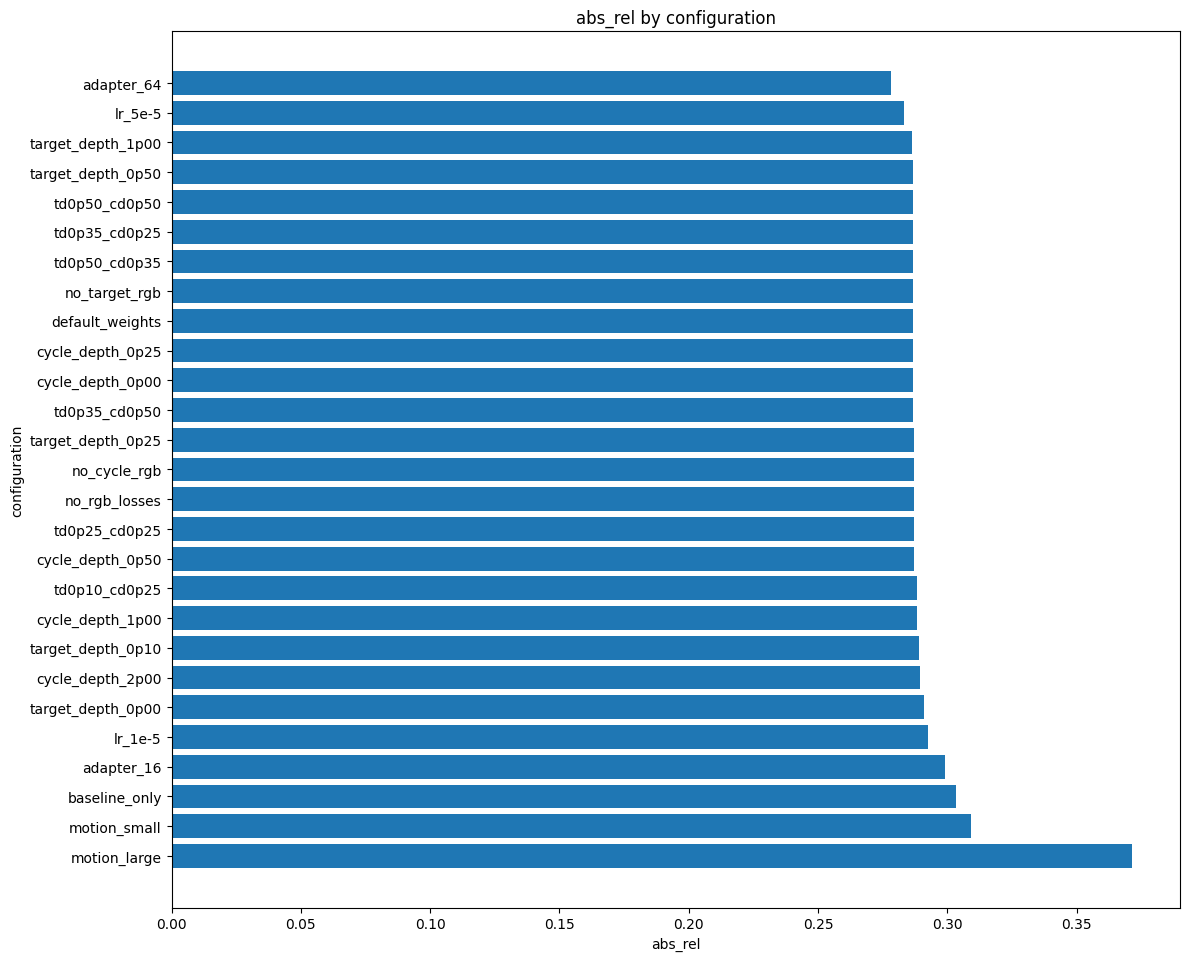

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\abs_rel_by_config.png


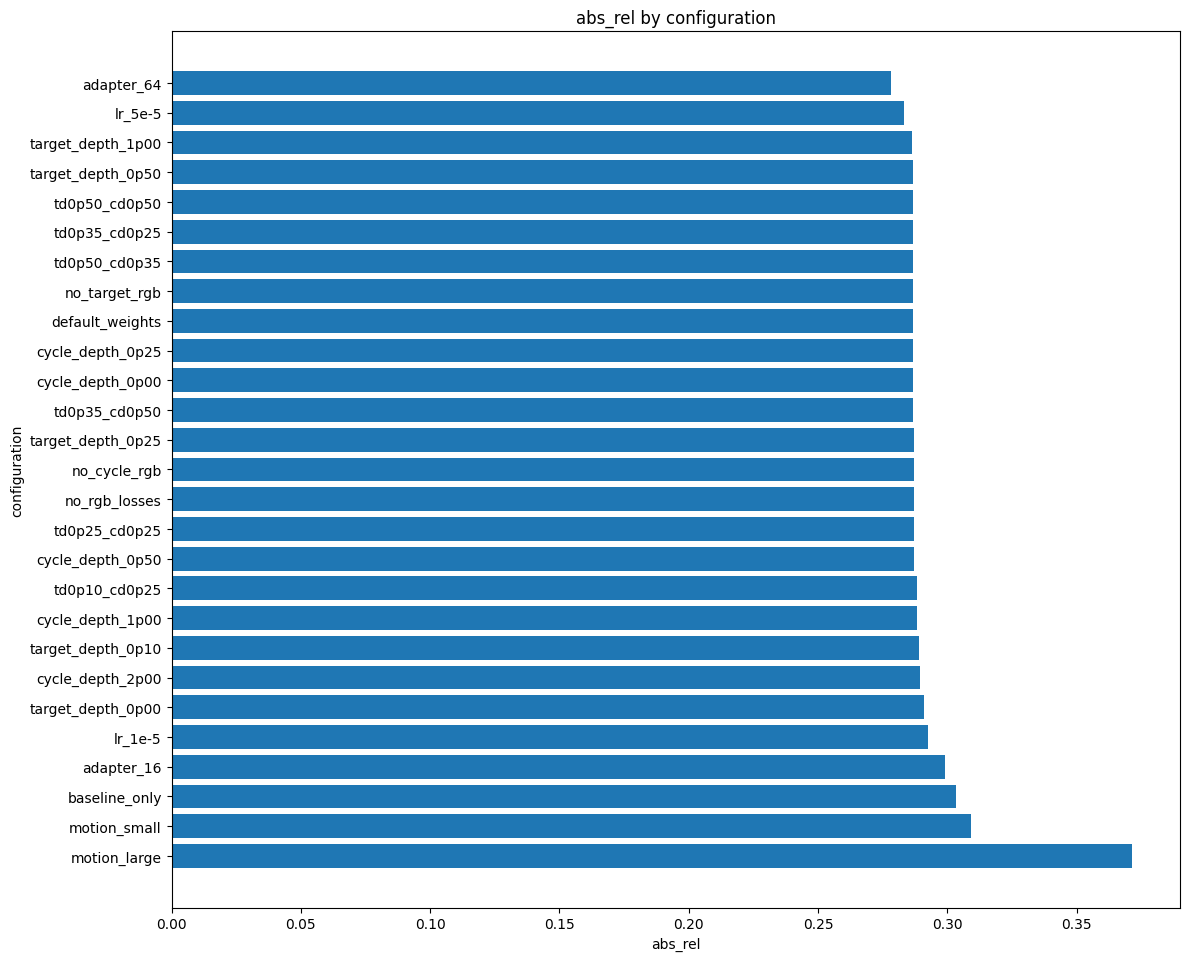

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\abs_rel_by_config.png


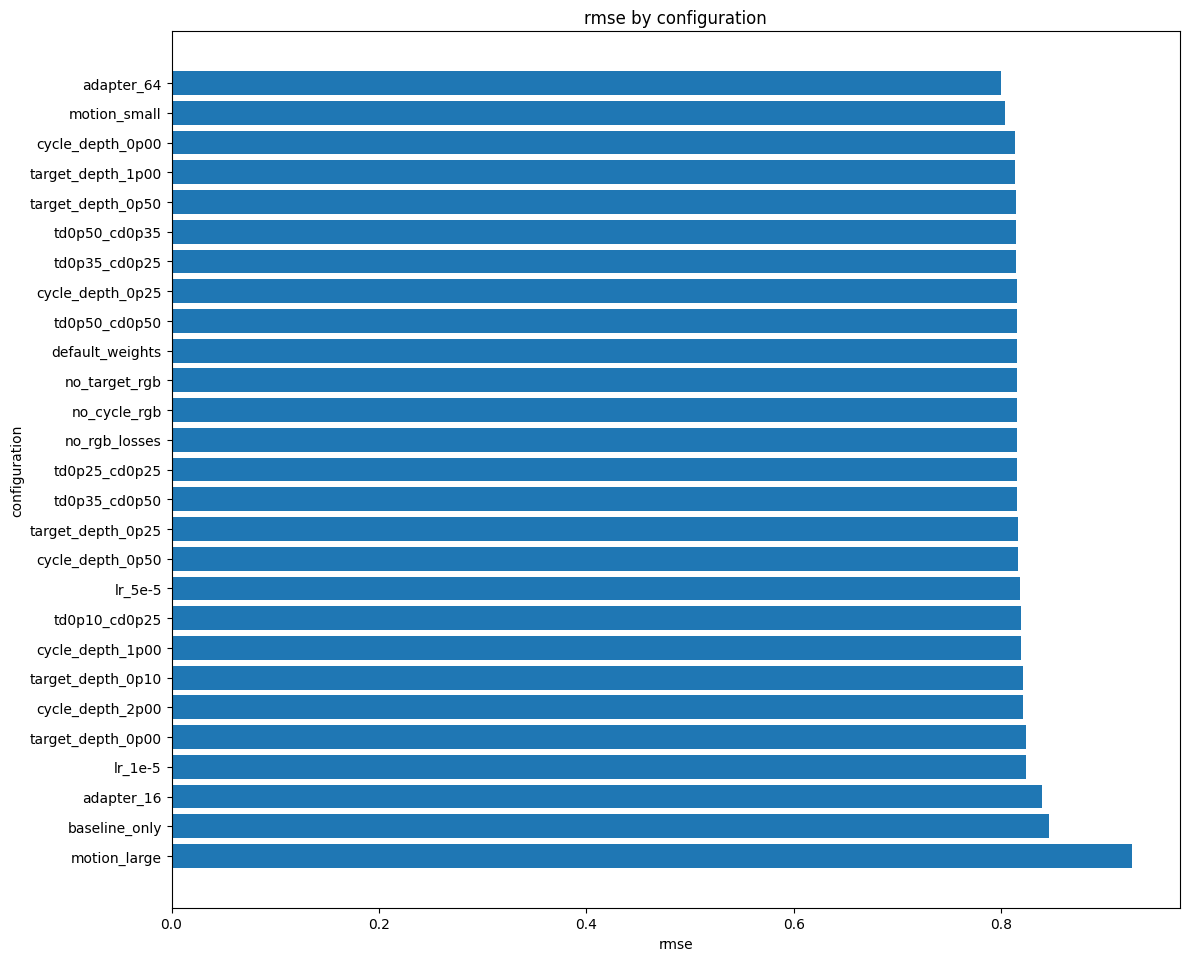

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\rmse_by_config.png


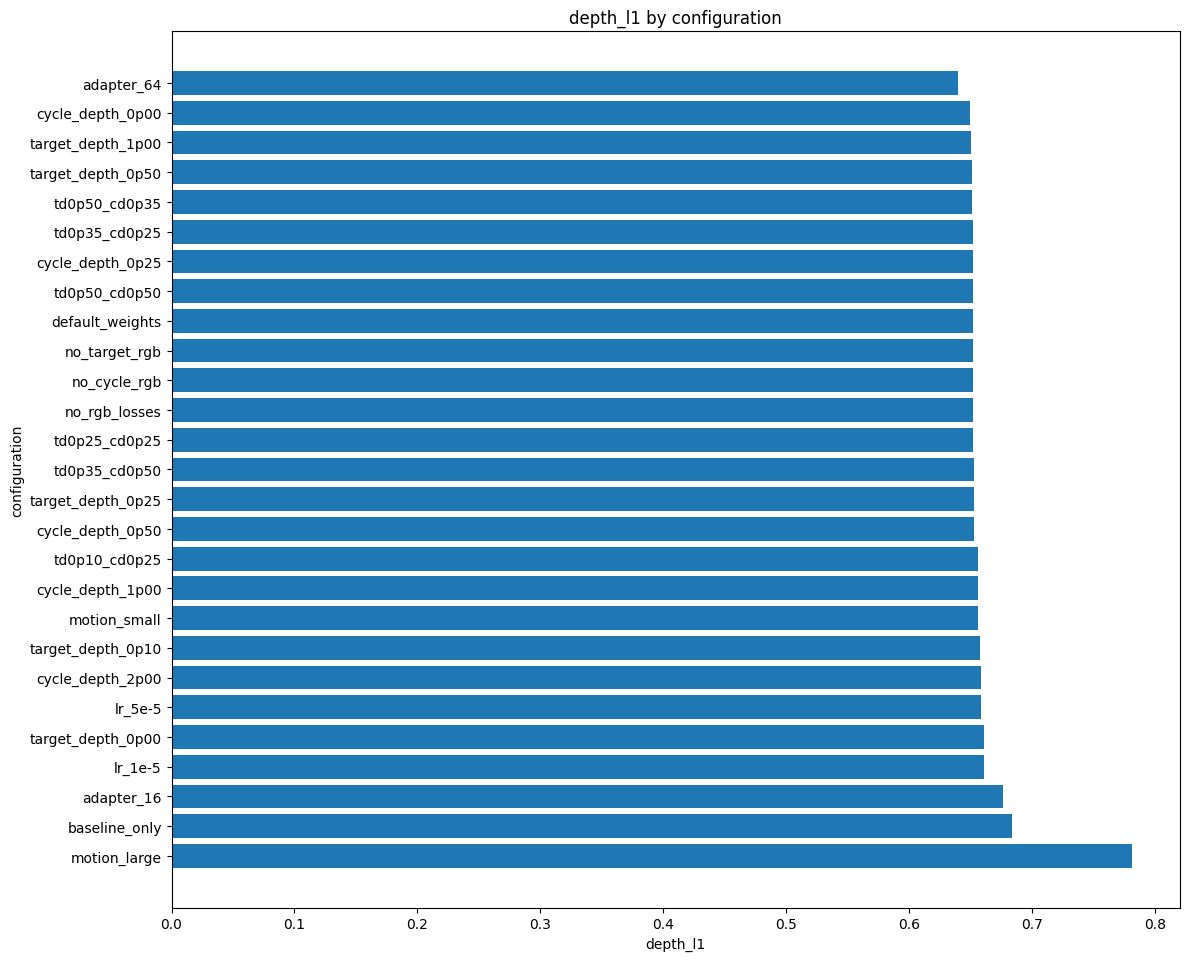

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\depth_l1_by_config.png


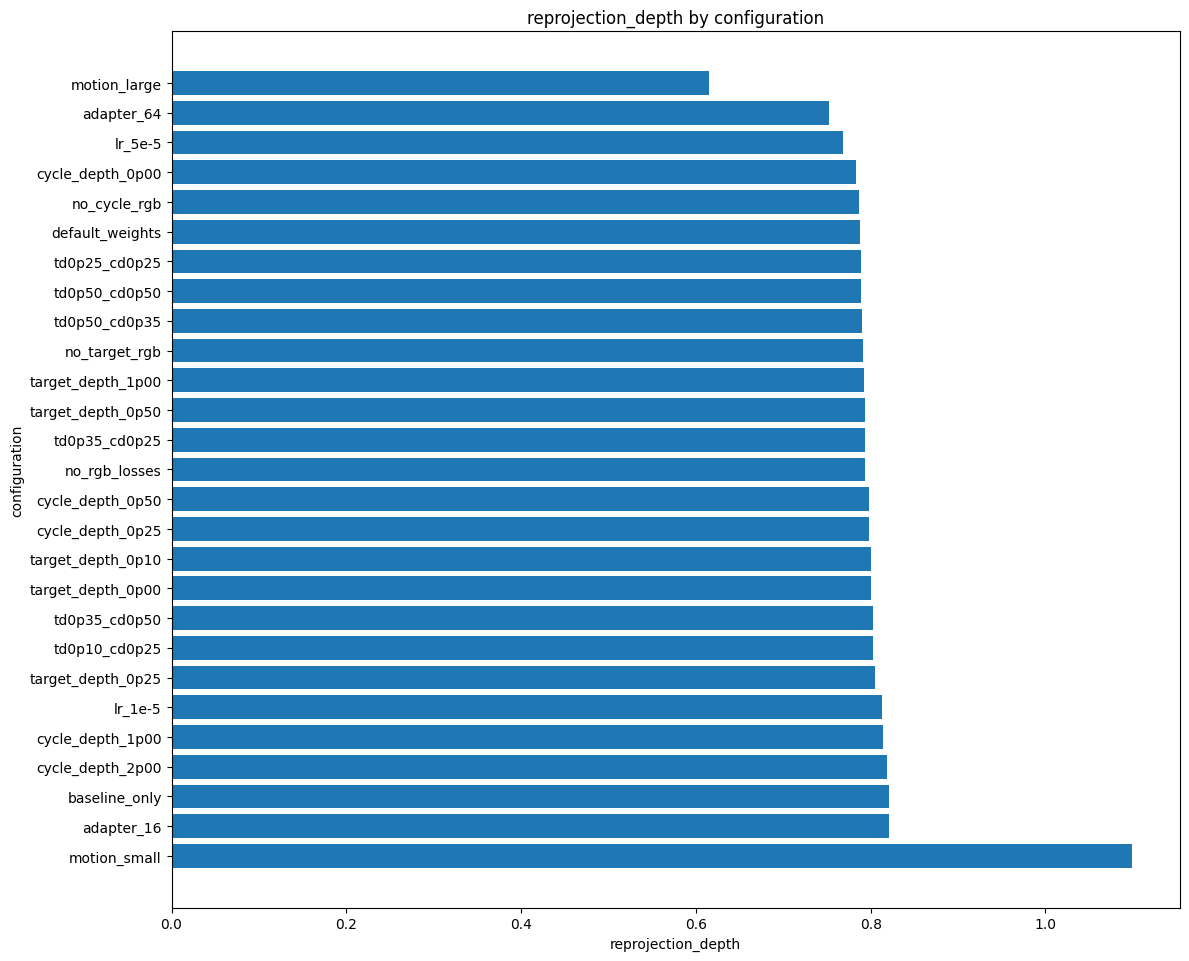

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\reprojection_depth_by_config.png


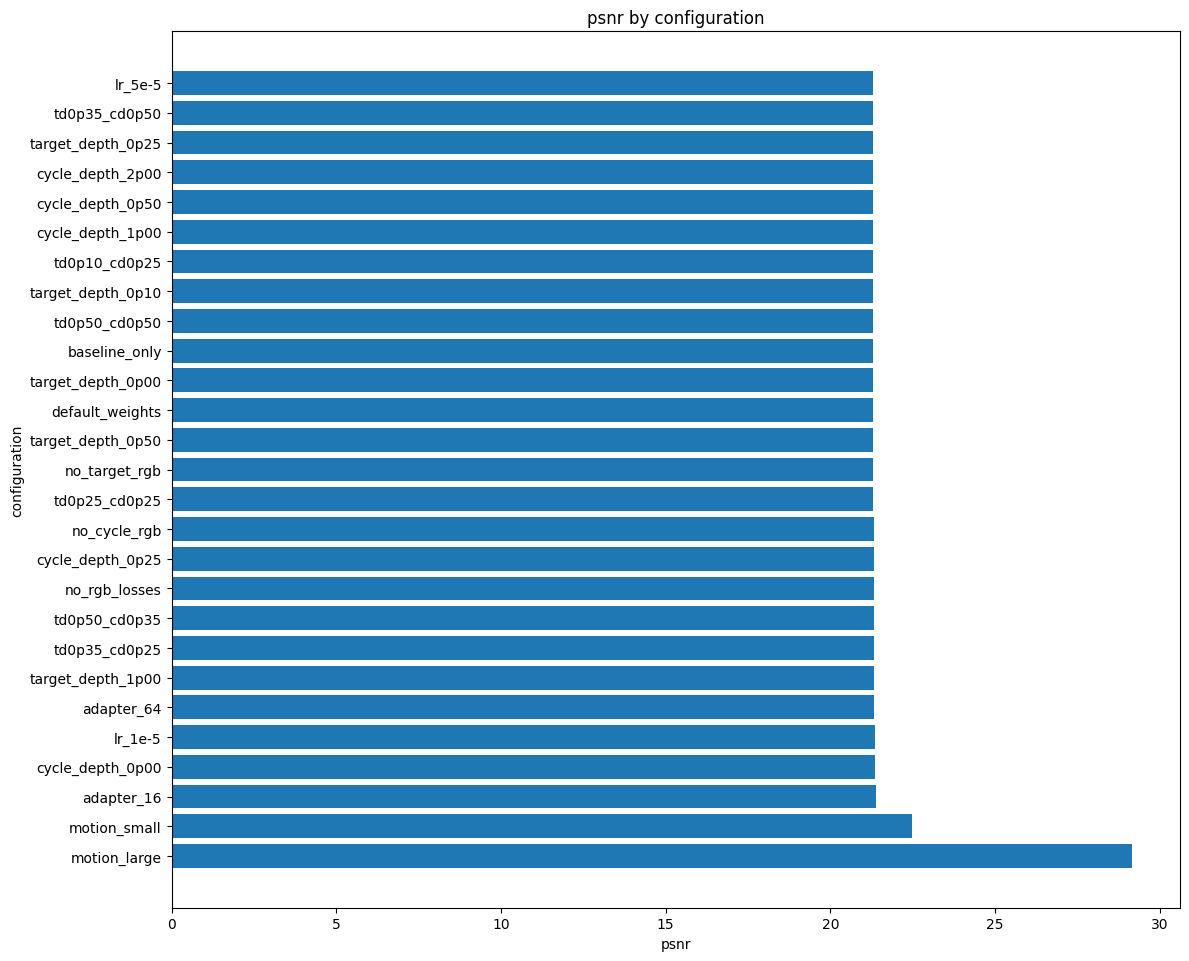

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\psnr_by_config.png


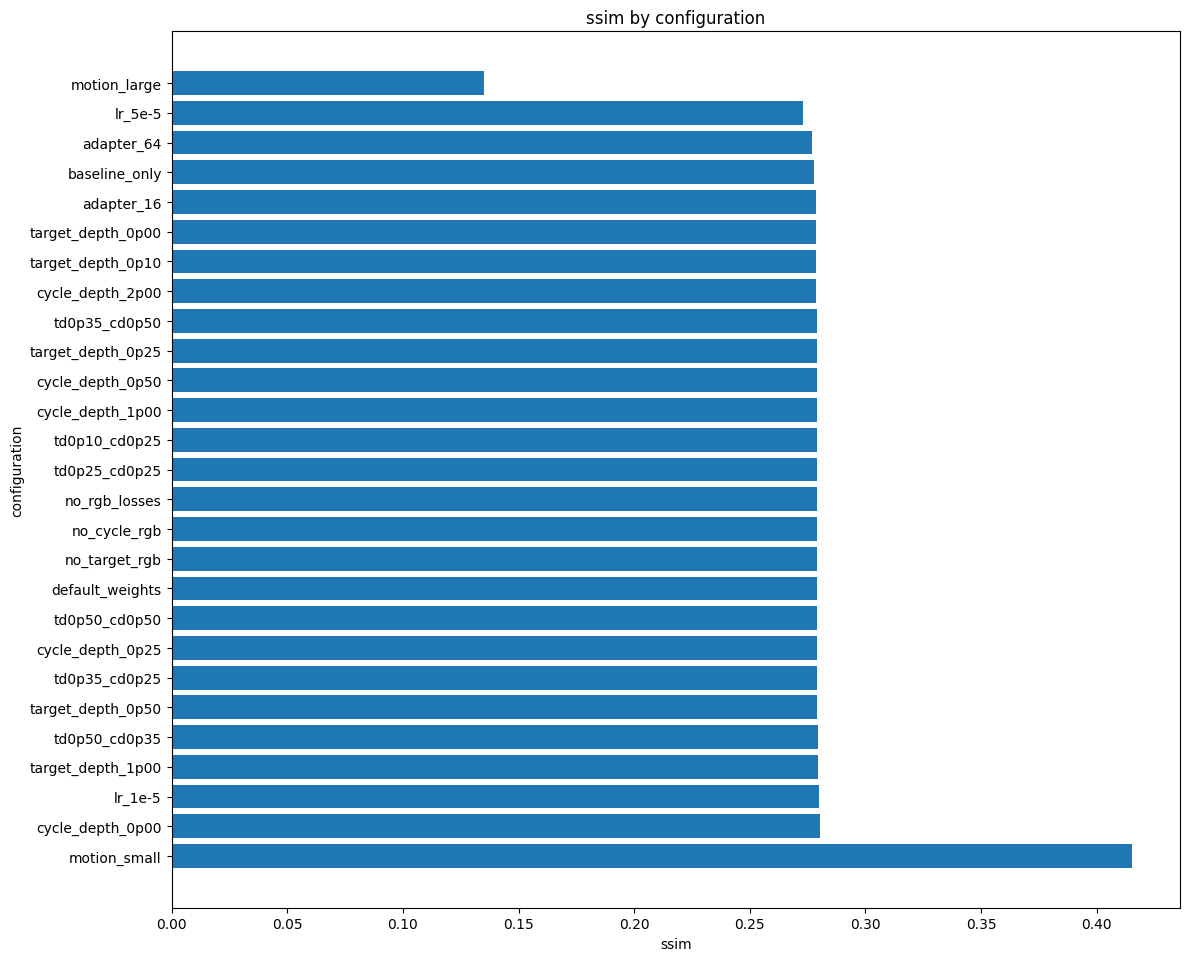

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\ssim_by_config.png


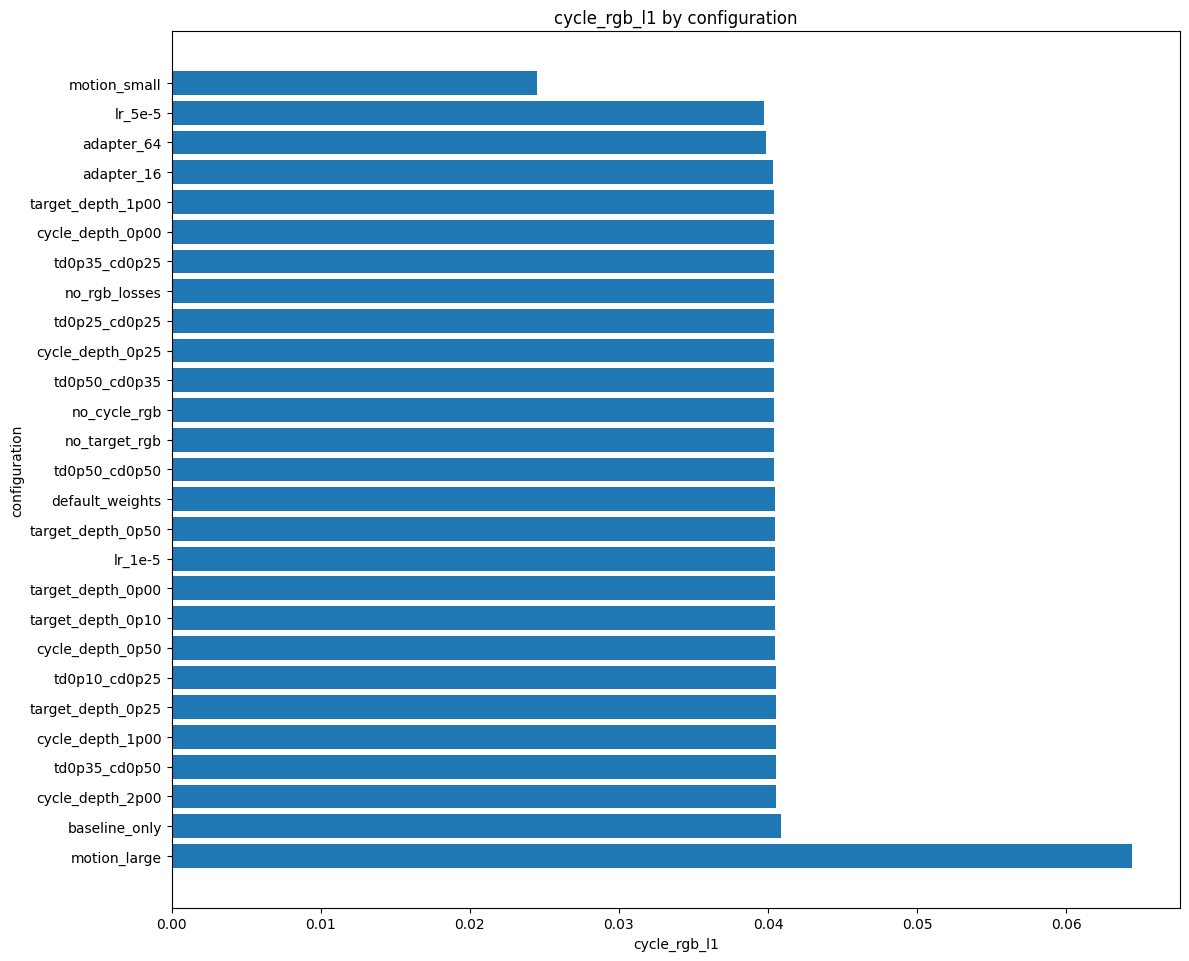

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\cycle_rgb_l1_by_config.png


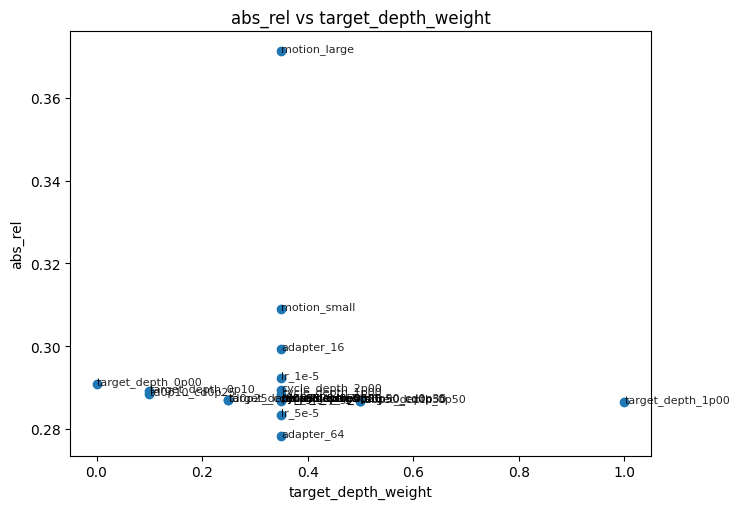

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\abs_rel_vs_target_depth_weight.png


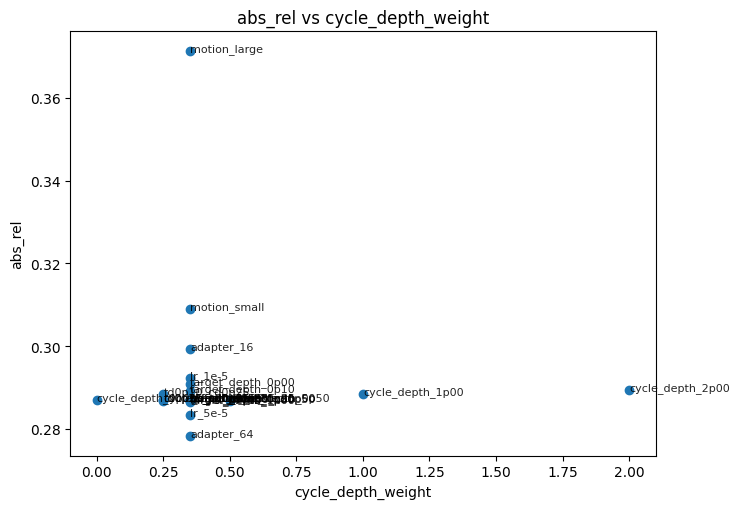

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\abs_rel_vs_cycle_depth_weight.png


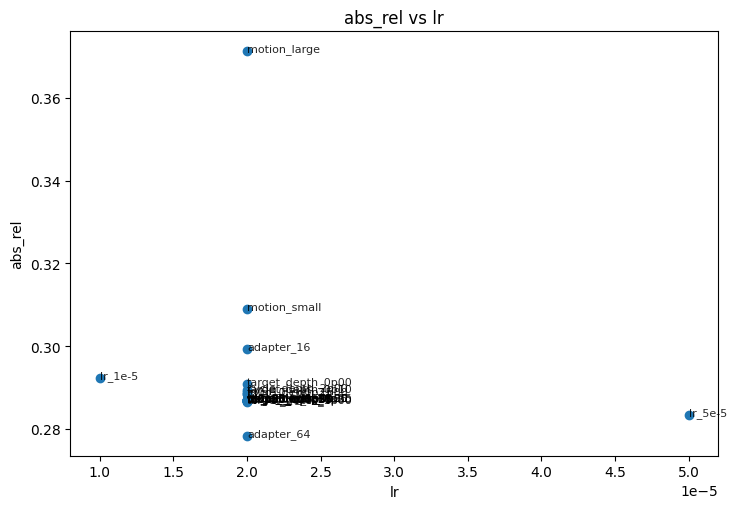

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\abs_rel_vs_lr.png


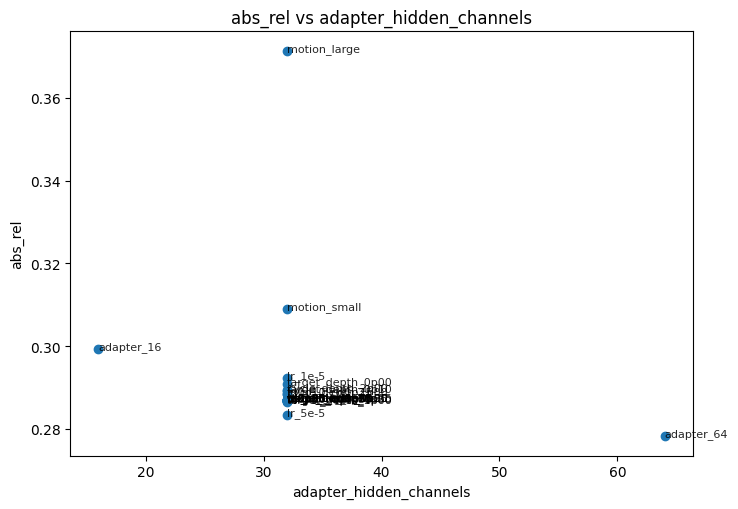

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\abs_rel_vs_adapter_hidden_channels.png


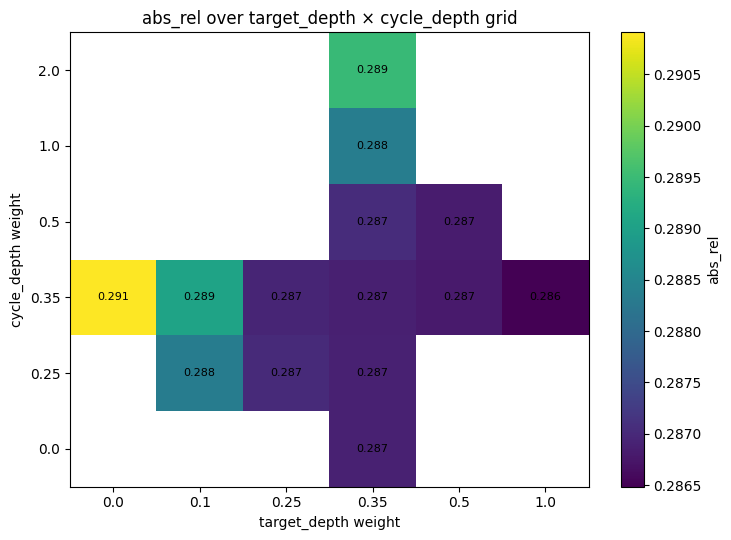

Saved: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_runs_local_cuda\metrics\plots\abs_rel_depth_weight_grid_heatmap.png
Total plots saved: 13


In [21]:
# =========================
# PLOTS
# =========================

import matplotlib.pyplot as plt

print_header("Generating plots")

plots_dir = ensure_dir(metrics_dir / "plots")

plot_df = ok_df.copy()

def save_bar_metric(df, metric):
    if metric not in df.columns or df.empty:
        return None

    ascending = metric not in HIGHER_IS_BETTER
    tmp = df.sort_values(metric, ascending=ascending).copy()

    plt.figure(figsize=(12, max(4, 0.36 * len(tmp))))
    plt.barh(tmp["name"], tmp[metric])
    plt.xlabel(metric)
    plt.ylabel("configuration")
    plt.title(f"{metric} by configuration")
    if ascending:
        plt.gca().invert_yaxis()
    plt.tight_layout()

    out = plots_dir / f"{metric}_by_config.png"
    plt.savefig(out, dpi=180)
    plt.show()
    print(f"Saved: {out}")
    return out

def save_scatter_metric(df, x_col, y_col, title=None):
    if x_col not in df.columns or y_col not in df.columns:
        return None

    tmp = df[[x_col, y_col, "name", "kind"]].dropna().copy()
    tmp = tmp[tmp["kind"] == "ablation"] if "kind" in tmp.columns else tmp

    if tmp.empty or tmp[x_col].nunique() <= 1:
        return None

    plt.figure(figsize=(7.5, 5.2))
    plt.scatter(tmp[x_col], tmp[y_col])
    for _, row in tmp.iterrows():
        plt.annotate(str(row["name"]), (row[x_col], row[y_col]), fontsize=8, alpha=0.85)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title or f"{y_col} vs {x_col}")
    plt.tight_layout()

    safe_x = x_col.replace("/", "_")
    safe_y = y_col.replace("/", "_")
    out = plots_dir / f"{safe_y}_vs_{safe_x}.png"
    plt.savefig(out, dpi=180)
    plt.show()
    print(f"Saved: {out}")
    return out

plot_files = []

for metric in [primary_metric, "abs_rel", "rmse", "depth_l1", "reprojection_depth", "psnr", "ssim", "cycle_rgb_l1"]:
    if metric in plot_df.columns:
        out = save_bar_metric(plot_df, metric)
        if out:
            plot_files.append(str(out))

for x_col in ["target_depth_weight", "cycle_depth_weight", "lr", "adapter_hidden_channels"]:
    out = save_scatter_metric(plot_df, x_col, primary_metric)
    if out:
        plot_files.append(str(out))


def save_depth_grid_heatmap(df, metric):
    required = {"target_depth_weight", "cycle_depth_weight", metric, "group"}
    if not required.issubset(df.columns):
        return None

    tmp = df[df["group"].isin(["depth_weight_grid", "default", "target_depth", "cycle_depth"])].copy()
    tmp = tmp.dropna(subset=["target_depth_weight", "cycle_depth_weight", metric])
    tmp = tmp.drop_duplicates(subset=["target_depth_weight", "cycle_depth_weight"], keep="first")

    if tmp.empty or tmp["target_depth_weight"].nunique() < 2 or tmp["cycle_depth_weight"].nunique() < 2:
        return None

    pivot = tmp.pivot_table(
        index="cycle_depth_weight",
        columns="target_depth_weight",
        values=metric,
        aggfunc="mean",
    ).sort_index(ascending=True).sort_index(axis=1, ascending=True)

    plt.figure(figsize=(7.5, 5.5))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns])
    plt.yticks(range(len(pivot.index)), [str(y) for y in pivot.index])
    plt.xlabel("target_depth weight")
    plt.ylabel("cycle_depth weight")
    plt.title(f"{metric} over target_depth × cycle_depth grid")
    plt.colorbar(label=metric)

    for i, y in enumerate(pivot.index):
        for j, x in enumerate(pivot.columns):
            val = pivot.loc[y, x]
            if pd.notna(val):
                plt.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    out = plots_dir / f"{metric}_depth_weight_grid_heatmap.png"
    plt.savefig(out, dpi=180)
    plt.show()
    print(f"Saved: {out}")
    return out


heatmap_out = save_depth_grid_heatmap(plot_df, primary_metric)
if heatmap_out:
    plot_files.append(str(heatmap_out))

with open(metrics_dir / "plot_files.json", "w", encoding="utf-8") as f:
    json.dump(plot_files, f, indent=2)

print(f"Total plots saved: {len(plot_files)}")


## 15. Auto-generate final analysis report

This cell writes a Markdown report based on the actual results.

The report includes:

- experiment setup
- best configuration
- ranked table
- baseline vs default comparison
- per-ablation-group observations
- failed run summary
- paper-ready conclusion paragraph


In [22]:
# =========================
# AUTO-GENERATED REPORT
# =========================

print_header("Generating final analysis report")

def fmt_value(x):
    try:
        if pd.isna(x):
            return "NA"
    except Exception:
        pass
    if isinstance(x, float):
        return f"{x:.6f}"
    return str(x)

def direction(metric):
    return "higher is better" if metric in HIGHER_IS_BETTER else "lower is better"

def best_for_metric(df, metric):
    if metric not in df.columns or df.empty:
        return None
    ascending = metric not in HIGHER_IS_BETTER
    return df.sort_values(metric, ascending=ascending).iloc[0]

def summarize_group(group_name):
    sub = rank_df[rank_df.get("group", "") == group_name].copy()
    if sub.empty:
        return f"No successful `{group_name}` runs were available."
    best = sub.iloc[0]
    return (
        f"Best `{group_name}` run by mean rank was `{best['name']}` "
        f"with `{primary_metric}={fmt_value(best[primary_metric])}`."
    )

def failed_run_summary(df):
    if "status" not in df.columns:
        return "No status column was available."
    failed = df[df["status"] != "ok"].copy()
    if failed.empty:
        return "No failed or incomplete runs were recorded."
    lines = [f"{len(failed)} failed/non-complete run(s) were recorded:"]
    for _, row in failed.iterrows():
        log_ref = row.get("train_log", None) or row.get("eval_log", None) or "NA"
        lines.append(f"- `{row.get('name', 'unknown')}`: `{row.get('status', 'unknown')}`. Log: `{log_ref}`")
    return "\n".join(lines)

best_row = rank_df.iloc[0]

report_lines = []
report_lines.append("# EagleVision Hyperparameter Ablation Report")
report_lines.append("")
report_lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append("")
report_lines.append("## 1. Experimental setup")
report_lines.append("")
report_lines.append(f"- Repository: `{REPO_URL}`")
report_lines.append(f"- Runtime profile: `{RUN_PROFILE}`")
report_lines.append(f"- Ablation preset: `{ABLATION_PRESET}`")
report_lines.append(f"- Device: `{DEVICE}`")
report_lines.append(f"- Encoder: `{ENCODER}`")
report_lines.append(f"- Depth mode/profile: `{DEPTH_MODE}` / `{DEPTH_PROFILE}`")
report_lines.append(f"- Checkpoint path: `{CHECKPOINT_PATH}`")
report_lines.append(f"- Image size: `{IMAGE_SIZE}`")
report_lines.append(f"- Attached-notebook style split: `{TRAIN_SCENE_FRACTION:.2f}` train fraction")
report_lines.append(f"- Scene limit: `{SCENE_LIMIT}`")
report_lines.append(f"- Default loss weights: `{DEFAULT_WEIGHTS}`")
report_lines.append(f"- Epochs: `{EPOCHS}`")
report_lines.append(f"- Max steps per epoch: `{MAX_STEPS_PER_EPOCH}`")
report_lines.append(f"- Max eval batches: `{MAX_EVAL_BATCHES}`")
report_lines.append(f"- Batch size: `{BATCH_SIZE}`")
report_lines.append(f"- Train scenes: `{len(train_scenes)}`")
report_lines.append(f"- Validation scenes: `{len(val_scenes)}`")
report_lines.append(f"- Pairing config: `{PAIRING}`")
report_lines.append("")

if CHECKPOINT_PATH is None:
    report_lines.append("> **Warning:** No pretrained checkpoint was loaded. These results should be treated as pipeline/debug ablations, not final pretrained Depth Anything V2 results.")
    report_lines.append("")

report_lines.append("## 2. Ablation goal")
report_lines.append("")
report_lines.append(
    "The ablation studies how EagleVision's adapter training responds to different loss balances and optimization settings. "
    "The most important tested hyperparameters are the `target_depth` weight and the `cycle_depth` weight, because these directly control the trade-off between metric depth anchoring and round-trip geometric consistency. This notebook follows the attached baseline notebook's data, image-size, pairing, checkpoint, and evaluation setup, while reducing epochs for feasible ablation. The full suite also tests their interaction, RGB-loss dependence, optimizer sensitivity, adapter capacity, and camera-motion robustness."
)
report_lines.append("")
report_lines.append("## 3. Main result")
report_lines.append("")
report_lines.append(
    f"The best configuration by mean metric rank was `{best_row['name']}`. "
    f"Using the primary metric `{primary_metric}` ({direction(primary_metric)}), it achieved `{primary_metric}={fmt_value(best_row[primary_metric])}`."
)
report_lines.append("")
report_lines.append("Top ranked configurations:")
report_lines.append("")
top_cols = [c for c in ["name", "group", primary_metric, "mean_rank", "target_depth_weight", "cycle_depth_weight", "lr", "adapter_hidden_channels"] if c in rank_df.columns]
report_lines.append(rank_df[top_cols].head(10).to_markdown(index=False))
report_lines.append("")
report_lines.append("## 4. Metric-specific best runs")
report_lines.append("")
for metric in available_lower + available_higher:
    row = best_for_metric(ok_df, metric)
    if row is not None:
        report_lines.append(f"- Best `{metric}` ({direction(metric)}): `{row['name']}` = `{fmt_value(row[metric])}`")
report_lines.append("")
report_lines.append("## 5. Ablation-group observations")
report_lines.append("")
for group_name in ["target_depth", "cycle_depth", "depth_weight_grid", "learning_rate", "adapter_capacity", "rgb_loss", "motion_range"]:
    report_lines.append(f"- {summarize_group(group_name)}")
report_lines.append("")
report_lines.append("## 6. Baseline comparison")
report_lines.append("")
if "baseline_only" in set(ok_df["name"]) and "default_weights" in set(ok_df["name"]):
    baseline = ok_df[ok_df["name"] == "baseline_only"].iloc[0]
    default = ok_df[ok_df["name"] == "default_weights"].iloc[0]
    report_lines.append("Baseline-only and default adapted model both completed successfully.")
    for metric in [primary_metric, "abs_rel", "rmse", "depth_l1", "reprojection_depth", "psnr", "ssim"]:
        if metric in ok_df.columns:
            delta = default[metric] - baseline[metric]
            report_lines.append(f"- `{metric}`: baseline `{fmt_value(baseline[metric])}`, default `{fmt_value(default[metric])}`, delta `{fmt_value(delta)}`")
else:
    report_lines.append("A full baseline-vs-default comparison could not be computed because one of the two runs did not complete successfully.")
report_lines.append("")
report_lines.append("## 7. Failed or incomplete runs")
report_lines.append("")
report_lines.append(failed_run_summary(results_df))
report_lines.append("")
report_lines.append("## 8. Paper-ready summary")
report_lines.append("")
report_lines.append(
    "The hyperparameter ablation provides empirical justification for the final EagleVision configuration by comparing direct depth anchoring, round-trip depth consistency, optimizer sensitivity, and adapter capacity under a fixed data split and runtime budget. "
    "The target-depth sweep tests whether metric depth supervision is necessary, while the cycle-depth sweep tests whether the round-trip geometry term contributes useful consistency. The depth-weight grid tests whether the best configuration depends on the interaction between these two losses. The RGB-loss and motion-range ablations evaluate robustness beyond the core depth losses. "
    "A strong final configuration should reduce depth errors such as AbsRel/RMSE/Depth-L1 while preserving reasonable reconstruction metrics such as cycle RGB L1, PSNR, and SSIM. "
    "If the default or nearby configuration ranks best, it supports the selected balance between metric accuracy and geometric consistency. "
    "If a stronger target-depth or cycle-depth setting wins, the paper should report that the original default was improved through ablation and use the best validation configuration as the final setting."
)
report_lines.append("")
report_lines.append("## 9. Generated files")
report_lines.append("")
report_lines.append(f"- Results CSV: `{csv_path}`")
report_lines.append(f"- Results JSON: `{json_path}`")
report_lines.append(f"- Excel workbook: `{xlsx_path}`")
report_lines.append(f"- Ranked results: `{ranked_path}`")
report_lines.append(f"- Plots directory: `{plots_dir}`")
report_lines.append(f"- Scene discovery report: `{EXPERIMENT_ROOT / 'scene_discovery_report.csv'}`")
report_lines.append(f"- Fixed split: `{EXPERIMENT_ROOT / 'fixed_split.json'}`")

report_text = "\n".join(report_lines)
report_path = metrics_dir / "analysis_report.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)
print(f"\nSaved report: {report_path}")



Generating final analysis report
# EagleVision Hyperparameter Ablation Report

Generated: 2026-05-02 12:18:26

## 1. Experimental setup

- Repository: `https://github.com/alooboii/EagleVision.git`
- Runtime profile: `paper_reduced`
- Ablation preset: `paper_full`
- Device: `cuda`
- Encoder: `vits`
- Depth mode/profile: `metric` / `hypersim`
- Checkpoint path: `c:\Users\Omore\OneDrive\Desktop\Ablations\EagleVision\baseline\depth_anything_v2\checkpoints\depth_anything_v2_metric_hypersim_vits.pth`
- Image size: `[192, 288]`
- Attached-notebook style split: `0.90` train fraction
- Scene limit: `30`
- Default loss weights: `{'target_rgb': 1.0, 'cycle_rgb': 1.0, 'cycle_depth': 0.35, 'target_depth': 0.35}`
- Epochs: `5`
- Max steps per epoch: `300`
- Max eval batches: `780`
- Batch size: `1`
- Train scenes: `27`
- Validation scenes: `3`
- Pairing config: `{'min_translation_m': 0.02, 'max_translation_m': 0.3, 'min_rotation_deg': 0.8, 'max_rotation_deg': 8.0, 'max_index_gap': 10, 'frame_stride

## 16. Package final artifacts

This creates a zip file containing the numerical results, configs, report, plots, and logs.

Download this zip from Kaggle after the run.


In [23]:
# =========================
# ZIP ARTIFACTS
# =========================

print_header("Packaging final artifacts")

artifact_zip = WORK_DIR / "eaglevision_ablation_artifacts.zip"

if artifact_zip.exists():
    artifact_zip.unlink()

# Archive the experiment directory.
shutil.make_archive(str(artifact_zip).replace(".zip", ""), "zip", root_dir=EXPERIMENT_ROOT)

print(f"Created artifact zip: {artifact_zip}")
print("Download this zip from the Kaggle output panel.")



Packaging final artifacts
Created artifact zip: c:\Users\Omore\OneDrive\Desktop\Ablations\eaglevision_ablation_artifacts.zip
Download this zip from the Kaggle output panel.


## Final checklist for local CUDA run

Before using the results in the paper:

1. Confirm `torch.cuda.is_available()` is `True`.
2. Confirm `DATA_ROOT` points to the correct local ScanNet root.
3. For smoke mode, confirm the verification cell reports `Evaluation pairs > 0`.
4. Confirm all required rows in `ablation_results.csv` have `status = ok`.
5. Use `ablation_results.xlsx` for paper tables.
6. Use `ranked_ablation_results.csv` for best-configuration selection.
7. Use plots from `metrics/plots/`.
8. State the run budget clearly: scene limit, epochs, max steps per epoch, image size, pairing setup, and validation split.
9. For final paper results, switch from `RUN_PROFILE = "smoke"` to `RUN_PROFILE = "paper_reduced"` and from `ABLATION_PRESET = "minimal"` to `ABLATION_PRESET = "paper_full"`.
